(mmm_brand_metrics_long_term)=
# Long-Term Brand Effects in MMMs with Brand Metrics and a Bayesian VARX

Media mix models are very good at one thing: quantifying the short-term sales response to performance media. They are structurally blind to another: the slow accumulation of demand that brand marketing builds through mindset metrics such as awareness and consideration. Brand campaigns rarely trigger immediate purchases, so when brand spend enters an MMM as a regular channel the model usualy reports a relatively low direct effect. The brand-driven demand does not disappear, though. It shows up as a slow drift in *base sales*, which the MMM absorbs into its intercept and never attributes to anything.

This is a measurement failure, not a marketing failure, and it has a well-established remedy in the marketing science literature: model the purchase funnel explicitly and let brand marketing act on sales *through* the brand metrics. In this notebook we implement a two-stage Bayesian workflow to recover the full effect:

1. **Stage 1**: fit a PyMC-Marketing {class}`~pymc_marketing.mmm.mmm.MMM` with a **time-varying intercept** (a Hilbert Space Gaussian Process, as in {ref}`mmm_tv_intercept`). The model recovers the short-term channel contributions as usual, and the evolving intercept becomes an explicit estimate of the *dynamic baseline* where brand effects live.
2. **Stage 2**: extract the baseline and model the system {baseline, awareness, consideration} with a **Bayesian vector autoregression with exogenous inputs (VARX)** using the [impulso](https://github.com/thomaspinder/impulso) package, treating brand spend as the exogenous driver. The VARX's *dynamic multiplier* tells us how a unit of brand spend propagates through the funnel into the baseline, week by week, with full posterior uncertainty.

The total return on brand marketing is then the short-term effect (from the MMM, approximately zero here) plus the long-term effect (from the VARX dynamic multiplier). We work with simulated data so we can validate every estimate against a known ground truth.

The approach follows the purchase-journey framework of Cain (2022), and this notebook is a PyMC-Marketing port of the workflow popularized by Ryan O'Sullivan's post [Capturing the long-term causal effect of brand marketing](https://medium.com/@raz1470/capturing-the-long-term-causal-effect-of-brand-marketing-bc577621a627) and by 1749.io's [Measuring Marketing Effectiveness Over the Long-Term](https://1749.io/learn/f/measuring-marketing-effectiveness-over-the-long-term).

> Cain, P. M. (2022). "Modelling short- and long-term marketing effects in the consumer purchase journey." *International Journal of Research in Marketing*, 39(1), 96-116. [doi:10.1016/j.ijresmar.2021.06.006](https://doi.org/10.1016/j.ijresmar.2021.06.006)

```{note}
How does this notebook relate to its siblings?

- {ref}`mmm_var_budget_optimization` also couples an MMM with an impulso VARX, but for *budget allocation* over fast-moving engagement indicators. Here the VARX is used for *measurement*: quantifying long-term brand effects transmitted through mindset metrics into the MMM baseline.
- {ref}`mmm_tv_intercept` introduces the time-varying intercept machinery we use in Stage 1.
- {ref}`mmm_upper_funnel_causal_approach` and {ref}`mmm_funnel_mueffect` handle funnel mediation *inside* a single nested model. The two-stage approach here trades that elegance for the VARX's explicit treatment of persistence, feedback, and long-run dynamics.
```

## Prepare Notebook

In [1]:
import warnings

import arviz as az
import graphviz as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from impulso import (
    VAR,
    VARData,
    adf_test,
    compute_ma_phi,
    johansen_test,
    kpss_test,
    lag_matrices,
)
from impulso.samplers import NUTSSampler
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.hsgp_kwargs import HSGPKwargs
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

seed: int = sum(map(ord, "mmm_brand_metrics_long_term"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/arviz/__init__.py:110: MigrationWarning: arviz.InferenceData is no longer available on the arviz package; ArviZ now uses xarray's DataTree for the same role. See the migration guide: https://python.arviz.org/en/latest/user_guide/migration_guide.html#datatree
  warnings.warn(


## Business Problem and Causal Structure

Picture a direct-to-consumer brand with three and a half years of weekly data. The marketing team runs two always-on performance channels, `x1` (search-like) and `x2` (social-like), and a few times per year it launches an eight-week TV brand campaign, `brand_spend`. A weekly brand-tracking survey measures `awareness` and `consideration`. All monetary quantities are expressed in units of \$10k, so any ratio of incremental sales to spend is a unit-free ROI.

Our structural assumptions are summarized in the causal graph below. The performance channels act directly on sales with the usual adstock and saturation dynamics. Brand spend has **no direct edge to sales**: its entire effect flows through the funnel, lifting awareness, which feeds consideration, which drives *base sales* (the non-media demand level). Each funnel variable is persistent, so a brand campaign keeps paying back long after it ends.

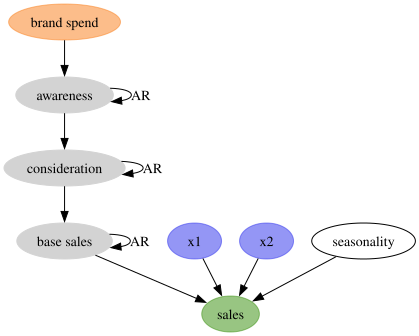

In [2]:
g = gr.Digraph()
g.node("brand spend", color="#fa7c1780", style="filled")
g.node("awareness", color="lightgray", style="filled")
g.node("consideration", color="lightgray", style="filled")
g.node("base sales", color="lightgray", style="filled")
g.node("x1", color="#2a2eec80", style="filled")
g.node("x2", color="#2a2eec80", style="filled")
g.node("seasonality")
g.node("sales", color="#328c0680", style="filled")
g.edge("brand spend", "awareness")
g.edge("awareness", "awareness", label="AR")
g.edge("awareness", "consideration")
g.edge("consideration", "consideration", label="AR")
g.edge("consideration", "base sales")
g.edge("base sales", "base sales", label="AR")
g.edge("base sales", "sales")
g.edge("x1", "sales")
g.edge("x2", "sales")
g.edge("seasonality", "sales")
g

Because there is no direct `brand spend -> sales` edge, a regression of sales on (transformed) brand spend estimates the *direct* short-term effect, which is genuinely zero. The *total* effect is the one the CMO cares about, and it lives on the mediated path. Our measurement strategy therefore has two stages:

| Stage | Model | Inputs | Output |
|---|---|---|---|
| 1 | MMM with time-varying intercept | sales, `x1`, `x2` | short-term contributions + dynamic baseline |
| 2 | Bayesian VARX (impulso) | baseline, `awareness`, `consideration`; `brand_spend` exogenous | dynamic multiplier of brand spend on the baseline |

## Simulate Data with a PyMC Generative Model

We simulate the data with PyMC models, following the pattern of the {ref}`mmm_data_generator` notebook: draw the covariates from a small PyMC model, then build a *generator* MMM on a dummy target, fix its parameters at true values with PyMC's {func}`~pymc.model.transform.conditioning.do` operator, and take a single prior predictive draw as the observed data. Everything downstream can then be validated against the stored ground truth.

We simulate `l_max` extra initial weeks and drop them afterwards, so that adstock carryover and the funnel recursions are properly warmed up.

In [3]:
l_max = 8
n_weeks = 182 + l_max

dates = pd.date_range(start="2021-01-04", periods=n_weeks, freq="W-MON")

coords = {"date": dates}

### Performance media spends

Two correlated, always-on channels drawn from a latent multivariate normal pushed through a softplus (so spends are positive), exactly as in the data generator notebook. The latent scale is chosen so that weekly spend sweeps a wide dynamic range, from near zero to well above the typical level. This is not just cosmetic: a saturation curve is only identifiable if the data visit both its toe and its shoulder, and always-on spend confined to a narrow band produces a ridge between the saturation parameters that no sampler can resolve.

In [4]:
spend_coords = {"date": dates, "channel_dim": ["x1", "x2"]}

spend_mu = np.array([-0.2, -0.9])
spend_sd = np.array([0.9, 1.1])
spend_corr = 0.4
spend_cov = (
    np.diag(spend_sd)
    @ np.array([[1.0, spend_corr], [spend_corr, 1.0]])
    @ np.diag(spend_sd)
)

with pm.Model(coords=spend_coords) as spend_model:
    spend_raw = pm.MvNormal(
        "spend_raw",
        mu=spend_mu,
        cov=spend_cov,
        dims=("date", "channel_dim"),
    )
    spend = pm.Deterministic(
        "spend", pt.softplus(spend_raw), dims=("date", "channel_dim")
    )

spend_draw = pm.draw(spend_model.spend, draws=1, random_seed=rng)
x1, x2 = spend_draw[:, 0], spend_draw[:, 1]

### Brand campaign flights

Brand spend is not drawn from a distribution: it is a *planned* schedule of four eight-week flights. This is deliberate and it matters for Stage 2. Because the flight calendar is set by the marketing team and does not react to weekly demand shocks, brand spend is exogenous to the funnel system, which is exactly the assumption the VARX dynamic multiplier needs to have a causal reading.

The flight start weeks are chosen to be irregular, so that the campaign pattern does not accidentally align with the yearly seasonal cycle (we verify the correlation is negligible below).

In [5]:
flight_starts = [7, 72, 99, 124]

brand_spend = np.zeros(n_weeks)
for start in flight_starts:
    s = start + l_max
    brand_spend[s : s + 8] = rng.uniform(0.9, 1.1, size=8)

seasonal_proxy = np.sin(2 * np.pi * np.arange(n_weeks) / 52.18)
corr_check = np.corrcoef(brand_spend, seasonal_proxy)[0, 1]
np.testing.assert_array_less(np.abs(corr_check), 0.1)
print(f"corr(brand flights, yearly cycle) = {corr_check:.3f}")

corr(brand flights, yearly cycle) = 0.007


### Brand funnel: awareness, consideration, and base sales

The funnel is a small structural time-series model, written as a PyMC model with a `pytensor.scan` recursion:

$$
\begin{aligned}
a_t &= \mu_a (1 - \rho_a) + \rho_a a_{t-1} + \gamma \, \text{brand}_t + \varepsilon^a_t \\
c_t &= \mu_c (1 - \rho_c) + \rho_c c_{t-1} + \delta \, a_{t-1} + \varepsilon^c_t \\
b_t &= b_0 (1 - \rho_b) + \rho_b b_{t-1} + \beta_c \, c_{t-1} + \varepsilon^b_t
\end{aligned}
$$

where $a$ is awareness, $c$ is consideration, and $b$ is base sales. Each equation is a stable AR(1) fed by the level above it in the funnel, so a brand campaign lifts awareness within the flight, consideration follows with a lag, and base sales drift upward over the following months. The survey we observe adds a little measurement noise on top of the latent awareness and consideration states.

A few parameter choices worth highlighting:

- $\rho_a = 0.90$ gives awareness a half-life of about 6.6 weeks: clearly persistent, but the response is mostly realized within a half-year evaluation window. Values very close to 1 make the long-run effect take years to materialize and are also harder to estimate in a short sample.
- Base sales has its own AR coefficient $\rho_b$ and innovation. This represents sales inertia (habit, repeat purchase) and it also matters statistically: if base sales were a deterministic function of consideration, the Stage-2 system {baseline, awareness, consideration} would be perfectly collinear by construction.

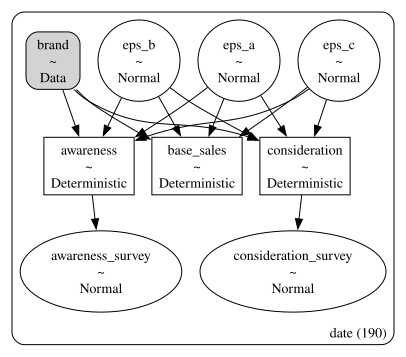

In [6]:
rho_a, gamma, mu_a, sigma_a = 0.90, 0.25, 1.0, 0.04
rho_c, delta, mu_c, sigma_c = 0.80, 0.4, 0.5, 0.03
rho_b, beta_c, base_ss, sigma_b = 0.5, 0.6, 3.5, 0.04
survey_sigma = 0.03

a_ss = mu_a
c_ss = mu_c + delta * a_ss / (1 - rho_c)
b0 = base_ss - beta_c * c_ss / (1 - rho_b)

with pm.Model(coords=coords) as funnel_model:
    brand = pm.Data("brand", brand_spend, dims="date")
    eps_a = pm.Normal("eps_a", mu=0, sigma=sigma_a, dims="date")
    eps_c = pm.Normal("eps_c", mu=0, sigma=sigma_c, dims="date")
    eps_b = pm.Normal("eps_b", mu=0, sigma=sigma_b, dims="date")

    def step(brand_t, ea_t, ec_t, eb_t, a_prev, c_prev, b_prev):
        a_t = mu_a * (1 - rho_a) + rho_a * a_prev + gamma * brand_t + ea_t
        c_t = mu_c * (1 - rho_c) + rho_c * c_prev + delta * a_prev + ec_t
        b_t = b0 * (1 - rho_b) + rho_b * b_prev + beta_c * c_prev + eb_t
        return a_t, c_t, b_t

    (a_seq, c_seq, b_seq) = pytensor.scan(
        fn=step,
        sequences=[brand, eps_a, eps_c, eps_b],
        outputs_info=[
            pt.constant(np.float64(a_ss)),
            pt.constant(np.float64(c_ss)),
            pt.constant(np.float64(base_ss)),
        ],
        return_updates=False,
    )
    awareness = pm.Deterministic("awareness", a_seq, dims="date")
    consideration = pm.Deterministic("consideration", c_seq, dims="date")
    base_sales = pm.Deterministic("base_sales", b_seq, dims="date")

    awareness_survey = pm.Normal(
        "awareness_survey", mu=awareness, sigma=survey_sigma, dims="date"
    )
    consideration_survey = pm.Normal(
        "consideration_survey", mu=consideration, sigma=survey_sigma, dims="date"
    )

pm.model_to_graphviz(funnel_model)

In [7]:
(
    awareness_true,
    consideration_true,
    base_sales_true,
    awareness_obs,
    consideration_obs,
) = pm.draw(
    [
        funnel_model.awareness,
        funnel_model.consideration,
        funnel_model.base_sales,
        funnel_model.awareness_survey,
        funnel_model.consideration_survey,
    ],
    draws=1,
    random_seed=rng,
)

### Sales: a generator MMM with `do` interventions

For the sales equation we reuse the {class}`~pymc_marketing.mmm.mmm.MMM` class itself as the data generator, so the short-term media effects follow exactly the adstock and saturation transformations the model will later estimate. The trick, borrowed from the data generator notebook, is to build the model on a dummy target of ones (which makes the internal max-abs scaling the identity) and then use {func}`pymc.do` to fix every parameter at its true value. Because the generator uses `time_varying_intercept=True`, the `intercept_contribution` variable has a `date` dimension, and we can intervene on it with the *entire true base sales path* from the funnel model above. A single prior predictive draw then produces the observed sales along with the true channel contributions.

In [8]:
intercept_tvp_config = HSGPKwargs(
    m=50, L=None, eta_lam=1.0, ls_mu=5.0, ls_sigma=10.0, cov_func=None
)

mmm_df = pd.DataFrame({"date": dates, "x1": x1, "x2": x2, "y_dummy": np.ones(n_weeks)})

mmm_generator = MMM(
    date_column="date",
    target_column="y_dummy",
    channel_columns=["x1", "x2"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config={"intercept_tvp_config": intercept_tvp_config},
)

X_generator = mmm_df.drop(columns=["y_dummy"])
mmm_generator.build_model(X_generator, mmm_df["y_dummy"])
mmm_generator.add_original_scale_contribution_variable(
    var=["channel_contribution", "intercept_contribution", "y"]
)

adstock_alpha_true = np.array([0.4, 0.2])
saturation_beta_true = np.array([1.2, 0.8])
saturation_lam_true = np.array([2.5, 2.0])
gamma_fourier_true = np.array([0.15, -0.1, 0.1, 0.05])
y_sigma_true = 0.12

mmm_generator.model = do(
    mmm_generator.model,
    {
        "intercept_contribution": base_sales_true,
        "adstock_alpha": adstock_alpha_true,
        "saturation_beta": saturation_beta_true,
        "saturation_lam": saturation_lam_true,
        "gamma_fourier": gamma_fourier_true,
        "y_sigma": y_sigma_true,
    },
)

with mmm_generator.model:
    idata_generator = pm.sample_prior_predictive(
        draws=1,
        var_names=[
            "y_original_scale",
            "channel_contribution_original_scale",
            "fourier_contribution",
        ],
        random_seed=rng,
    )

y_obs = idata_generator["prior"]["y_original_scale"].sel(chain=0, draw=0).to_numpy()
channel_contribution_true = (
    idata_generator["prior"]["channel_contribution_original_scale"]
    .sel(chain=0, draw=0)
    .to_numpy()
)
fourier_true = (
    idata_generator["prior"]["fourier_contribution"].sel(chain=0, draw=0).to_numpy()
)

Sampling: [y]


Finally we assemble the observed dataset (what an analyst would actually receive) and a separate truth table (what we keep for validation only), dropping the warm-up weeks.

In [9]:
df = (
    pd.DataFrame(
        {
            "date": dates,
            "x1": x1,
            "x2": x2,
            "brand_spend": brand_spend,
            "awareness": awareness_obs,
            "consideration": consideration_obs,
            "y": y_obs,
        }
    )
    .tail(-l_max)
    .reset_index(drop=True)
)

truth_df = (
    pd.DataFrame(
        {
            "date": dates,
            "base_sales": base_sales_true,
            "awareness_latent": awareness_true,
            "consideration_latent": consideration_true,
            "x1_contribution": channel_contribution_true[:, 0],
            "x2_contribution": channel_contribution_true[:, 1],
            "fourier": fourier_true.sum(axis=-1),
        }
    )
    .tail(-l_max)
    .reset_index(drop=True)
)

n_obs = len(df)

df.head()

,date,x1,x2,brand_spend,awareness,consideration,y
0,2021-03-01,0.437559,0.374785,0.0,0.989339,2.309587,3.863143
1,2021-03-08,0.152899,0.142339,0.0,0.979903,2.383373,3.649521
2,2021-03-15,1.008619,0.591242,0.0,1.014202,2.369849,3.850973
3,2021-03-22,0.299215,0.119386,0.0,1.056714,2.502459,3.794218
4,2021-03-29,0.634628,0.254614,0.0,1.010331,2.469223,3.919864


### Ground truth: the true dynamic multiplier of brand spend

Before fitting anything, let us compute the quantity we will try to recover. Propagating a one-unit, one-week pulse of brand spend through the noise-free funnel recursions gives the true impulse response of base sales, and its cumulative sum is the true *cumulative dynamic multiplier*: the total incremental base sales generated within $h$ weeks per unit of brand spend.

The infinite-horizon limit has a closed form, $\beta_c \delta \gamma / \left[(1-\rho_a)(1-\rho_c)(1-\rho_b)\right] = 6.0$. We will quote results at a 26-week horizon (27 weekly responses, $h = 0, \dots, 26$, including the impulse week), where about 86% of the long-run effect has been realized. The choice of horizon is an accounting convention, just like a payback window in finance, and it should be stated explicitly in any real analysis.

In [10]:
horizon = 26

impulse_a = np.zeros(horizon + 1)
impulse_c = np.zeros(horizon + 1)
impulse_b = np.zeros(horizon + 1)
impulse_a[0] = gamma

for h in range(1, horizon + 1):
    impulse_a[h] = rho_a * impulse_a[h - 1]
    impulse_c[h] = rho_c * impulse_c[h - 1] + delta * impulse_a[h - 1]
    impulse_b[h] = rho_b * impulse_b[h - 1] + beta_c * impulse_c[h - 1]

true_cum_multiplier = np.cumsum(impulse_b)
true_long_term_roi = true_cum_multiplier[-1]
asymptote = beta_c * delta * gamma / ((1 - rho_a) * (1 - rho_c) * (1 - rho_b))

print(f"true cumulative multiplier at h={horizon}: {true_long_term_roi:.2f}")
print(f"infinite-horizon asymptote: {asymptote:.2f}")
print(f"share realized within {horizon} weeks: {true_long_term_roi / asymptote:.1%}")

true_roi_x1 = truth_df["x1_contribution"].sum() / df["x1"].sum()
true_roi_x2 = truth_df["x2_contribution"].sum() / df["x2"].sum()
print(f"true short-term ROI x1: {true_roi_x1:.2f}, x2: {true_roi_x2:.2f}")

true cumulative multiplier at h=26: 5.15
infinite-horizon asymptote: 6.00
share realized within 26 weeks: 85.9%
true short-term ROI x1: 0.53, x2: 0.34


### A first look at the data

The plots below tell the story we will need to recover statistically: awareness climbs during every flight and decays afterwards, consideration follows more slowly, and sales drift upward on top of the short-term media noise.

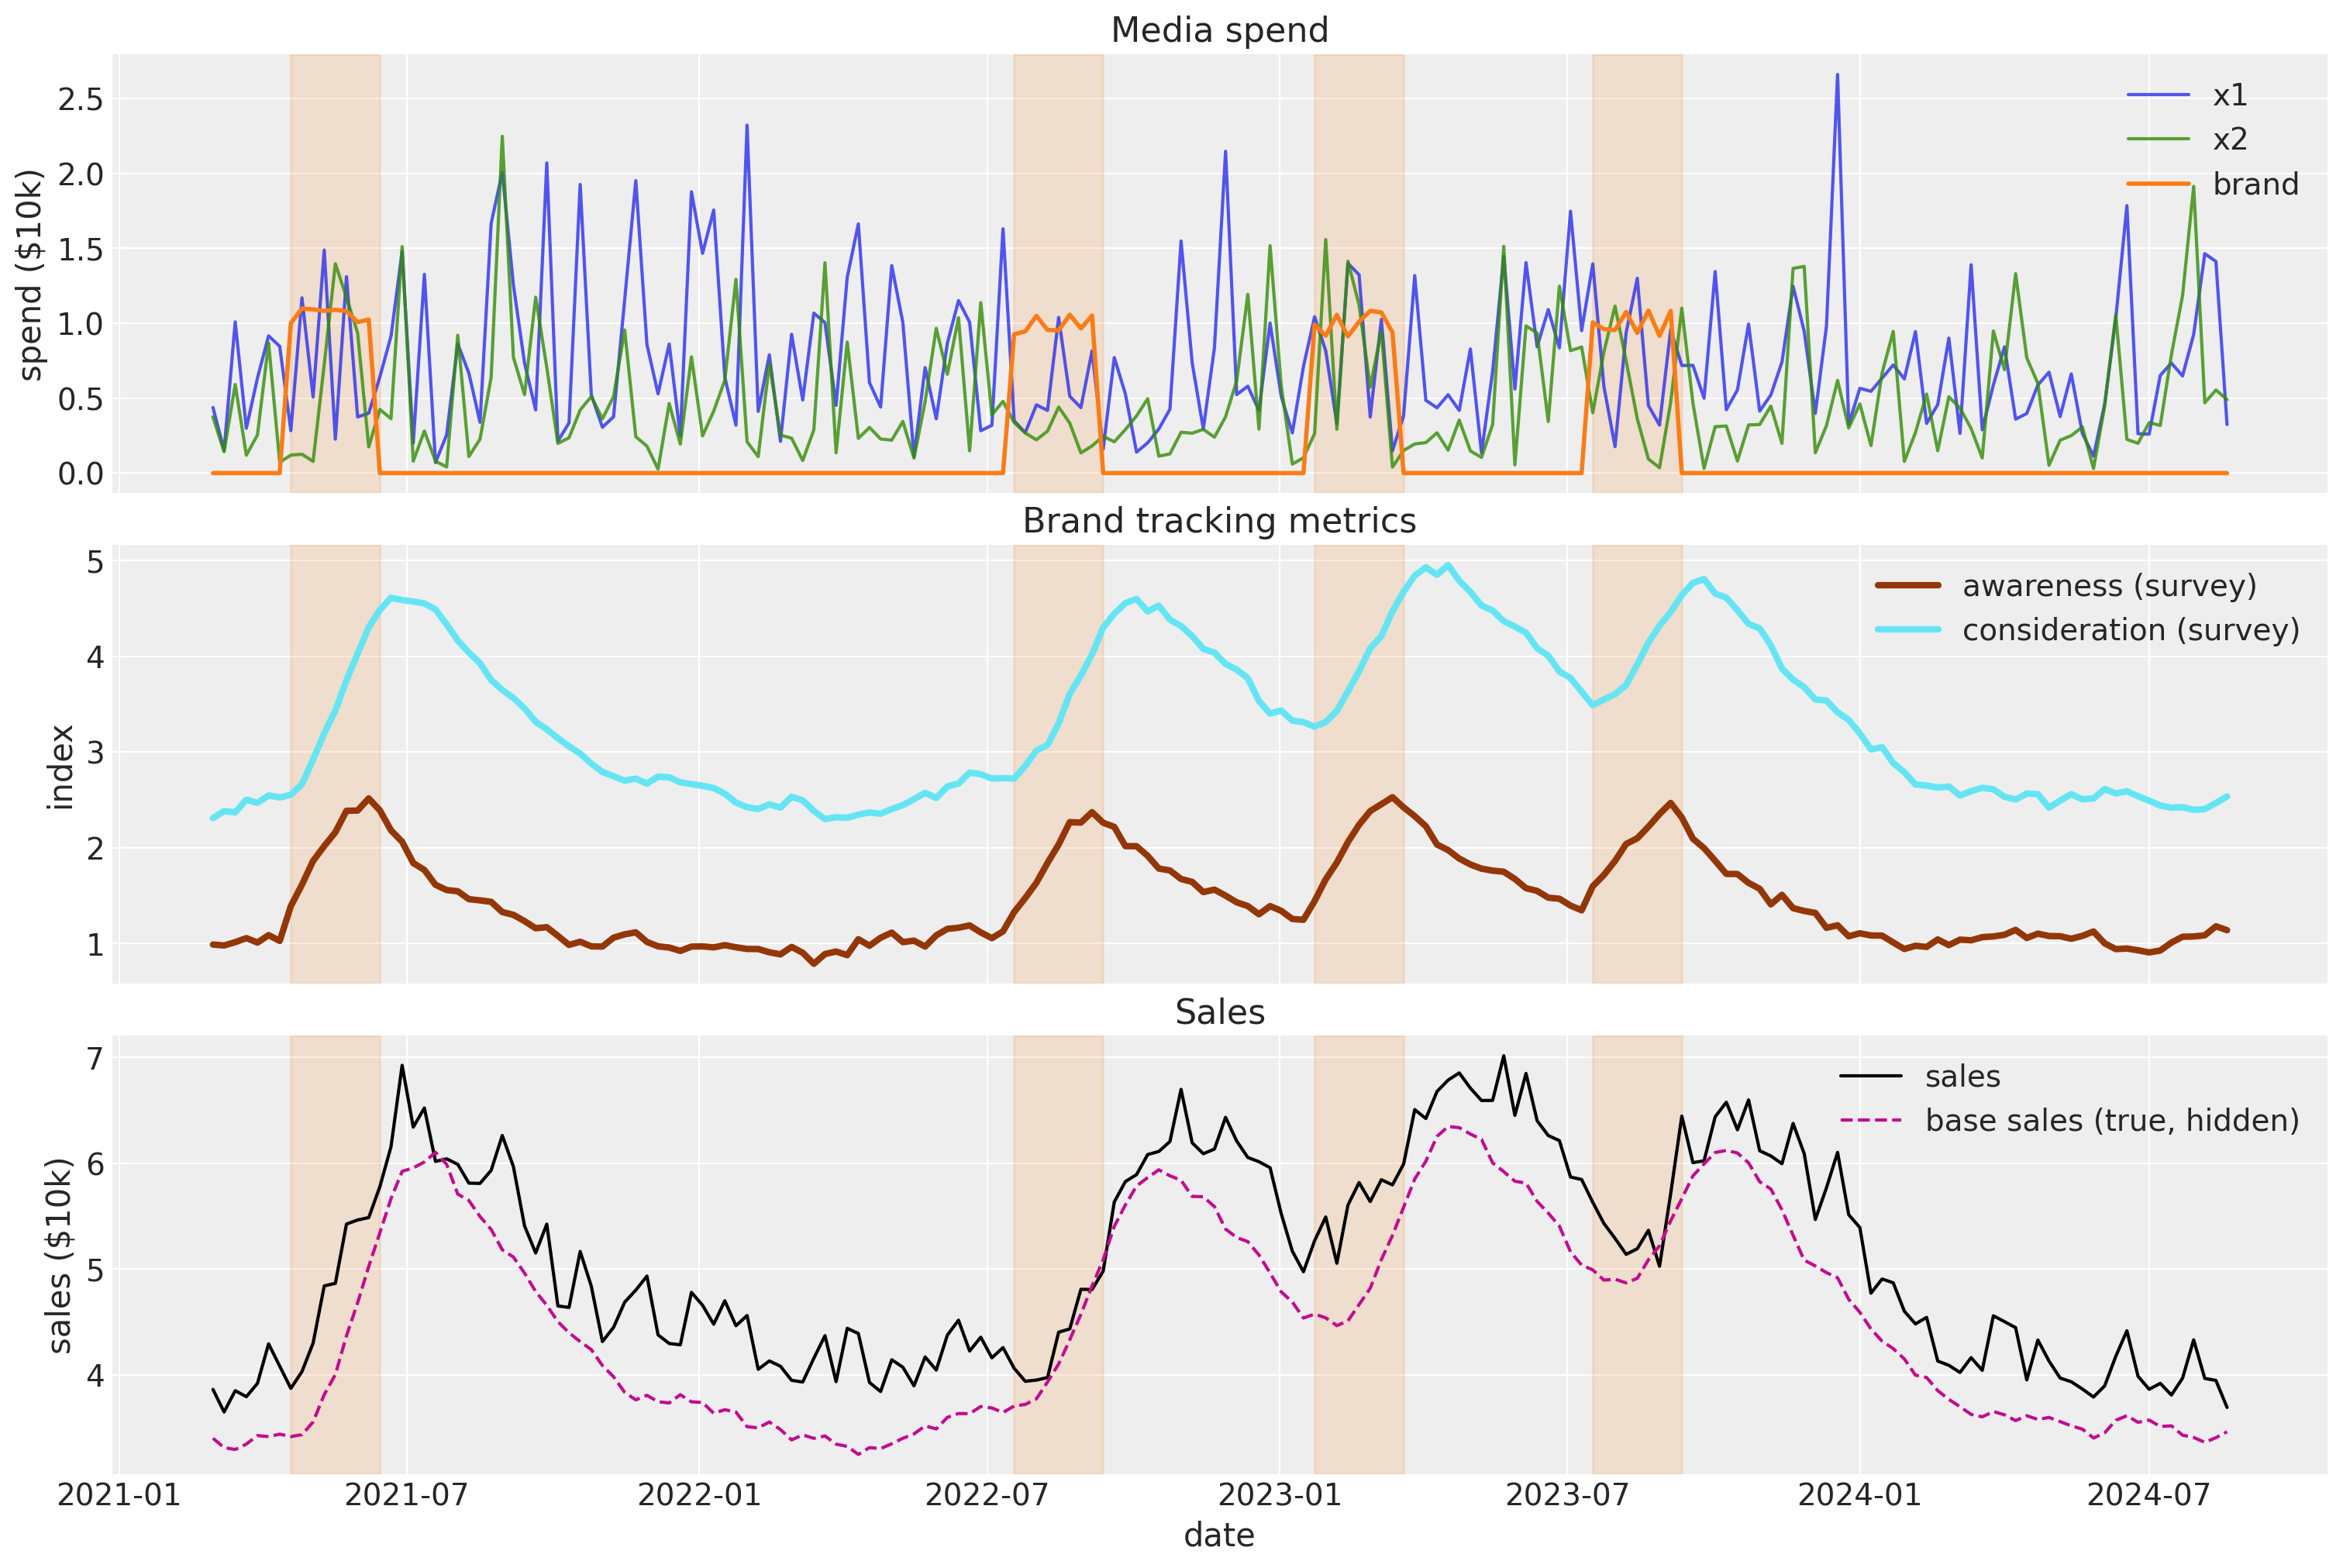

In [11]:
def shade_flights(ax):
    for start in flight_starts:
        left = dates[start + l_max]
        right = dates[min(start + l_max + 8, n_weeks - 1)]
        ax.axvspan(left, right, color="C1", alpha=0.15)


fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    sharey=False,
    figsize=(15, 10),
    layout="constrained",
)
axes[0].plot(df["date"], df["x1"], color="C0", alpha=0.8, label="x1")
axes[0].plot(df["date"], df["x2"], color="C2", alpha=0.8, label="x2")
axes[0].plot(df["date"], df["brand_spend"], color="C1", linewidth=2, label="brand")
shade_flights(axes[0])
axes[0].legend(loc="upper right")
axes[0].set(title="Media spend", ylabel="spend ($10k)")

axes[1].plot(
    df["date"],
    df["awareness"],
    color="C4",
    linewidth=3,
    label="awareness (survey)",
)
axes[1].plot(
    df["date"],
    df["consideration"],
    color="C5",
    linewidth=3,
    label="consideration (survey)",
)
shade_flights(axes[1])
axes[1].legend(loc="upper right")
axes[1].set(title="Brand tracking metrics", ylabel="index")

axes[2].plot(df["date"], df["y"], color="black", label="sales")
axes[2].plot(
    truth_df["date"],
    truth_df["base_sales"],
    color="C3",
    linestyle="--",
    label="base sales (true, hidden)",
)
shade_flights(axes[2])
axes[2].legend(loc="upper right")
axes[2].set(title="Sales", ylabel="sales ($10k)", xlabel="date");

## The Naive Approach: Brand Spend as a Regular MMM Channel

What most teams do first is add brand spend to the MMM as a third channel. Let us do exactly that, with a time-varying intercept and the same specification we will use later, and see what happens.

Two remarks on the specification. First, the `saturation_beta` prior scales with each channel's share of total spend. This prior is load-bearing in a model with a flexible intercept: without it, the sampler can trade the baseline against a channel contribution and the posterior becomes badly multimodal. Second, we always run four chains, so that any residual multimodality shows up in the diagnostics rather than silently biasing one chain's answer.

In [12]:
sampler_config = {
    "tune": 1_000,
    "draws": 1_000,
    "chains": 4,
    "nuts_sampler": "nutpie",
    "target_accept": 0.95,
    "random_seed": rng,
}

naive_channels = ["x1", "x2", "brand_spend"]
cost_share_naive = xr.DataArray(
    df[naive_channels].sum() / df[naive_channels].sum().sum(),
    dims="channel",
)

model_config_naive = {
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=2)),
    "gamma_fourier": Prior("Normal", mu=0, sigma=2, dims="fourier_mode"),
    "intercept_tvp_config": intercept_tvp_config,
    "adstock_alpha": Prior("Beta", alpha=2, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=2, beta=1, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=cost_share_naive, dims="channel"),
}

In [13]:
%%time
mmm_naive = MMM(
    date_column="date",
    target_column="y",
    channel_columns=naive_channels,
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config=model_config_naive,
)

X_naive = df[["date", *naive_channels]]
y = df["y"]

mmm_naive.build_model(X_naive, y)
mmm_naive.add_original_scale_contribution_variable(
    var=["channel_contribution", "intercept_contribution"]
)
_ = mmm_naive.fit(X_naive, y, **sampler_config)

NUTS[nutpie]: [intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, y_sigma]


Output()

Output()

CPU times: user 1min 30s, sys: 1.07 s, total: 1min 31s
Wall time: 28.7 s


In [14]:
az.diagnose(mmm_naive.idata)

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
The following parameters has fewer than 400 effective samples:
  intercept_latent_process_raw_hsgp_coefs_offset, intercept_baseline, gamma_fourier, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, adstock_alpha, saturation_lam, saturation_beta, y_sigma, intercept_contribution_original_scale, channel_contribution_original_scale, total_media_contribution_original_scale, yearly_seasonality_contribution, fourier_contribution, channel_contribution, intercept_contribution, intercept_latent_process, intercept_latent_process_f_mean, intercept_latent_process_raw, intercept_latent_process_raw_hsgp_coefs
This suggests that the sampler may not have fully explored the posterior distribution for this parameter.
Consider reparameterizing the model or increasing the number of samples.

R-hat
The following parameters has R-hat values greater than 1.01:
  intercept_latent_process_raw_hsgp_coefs

True

In [15]:
az.summary(
    mmm_naive.idata,
    var_names=["saturation_beta", "adstock_alpha", "saturation_lam"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
saturation_beta[x1],0.5,0.3,0.19,0.94,9,24,1.35,0.11,0.055
saturation_beta[x2],0.212,0.13,0.087,0.46,3606,2852,1.00,0.0024,0.0033
saturation_beta[brand_spend],0.0194,0.028,0.00061,0.071,3241,3701,1.01,0.00046,0.00087
adstock_alpha[x1],0.49,0.07,0.38,0.6,36,352,1.07,0.011,0.008
adstock_alpha[x2],0.221,0.09,0.085,0.37,2927,2641,1.01,0.0017,0.0012
adstock_alpha[brand_spend],0.477,0.229,0.12,0.85,4338,3162,1.00,0.0035,0.0019
saturation_lam[x1],1e+01,14,0.59,36,7,10,1.53,7,4.2
saturation_lam[x2],1.59,0.93,0.48,3.2,3663,2807,1.00,0.014,0.016
saturation_lam[brand_spend],1.39,1.33,0.12,3.9,4374,2893,1.00,0.021,0.027


The incremental ROI per channel comes from the {attr}`~pymc_marketing.mmm.mmm.MMM.incrementality` namespace, which computes counterfactual contributions with proper adstock carryover handling.

In [16]:
roi_naive = mmm_naive.incrementality.contribution_over_spend(
    frequency="all_time"
).rename("roi")

roi_naive_hdi = az.hdi(roi_naive, prob=0.94)
roi_naive_summary = pd.DataFrame(
    {
        "median": roi_naive.median(dim=("chain", "draw")).to_series(),
        "hdi_low": roi_naive_hdi.sel(ci_bound="lower").to_series(),
        "hdi_high": roi_naive_hdi.sel(ci_bound="upper").to_series(),
    }
)

roi_naive_summary

,median,hdi_low,hdi_high
channel,,,
x1,0.657879,0.386988,8.414937
x2,0.366613,0.264873,0.499291
brand_spend,0.022321,0.000004,0.123926


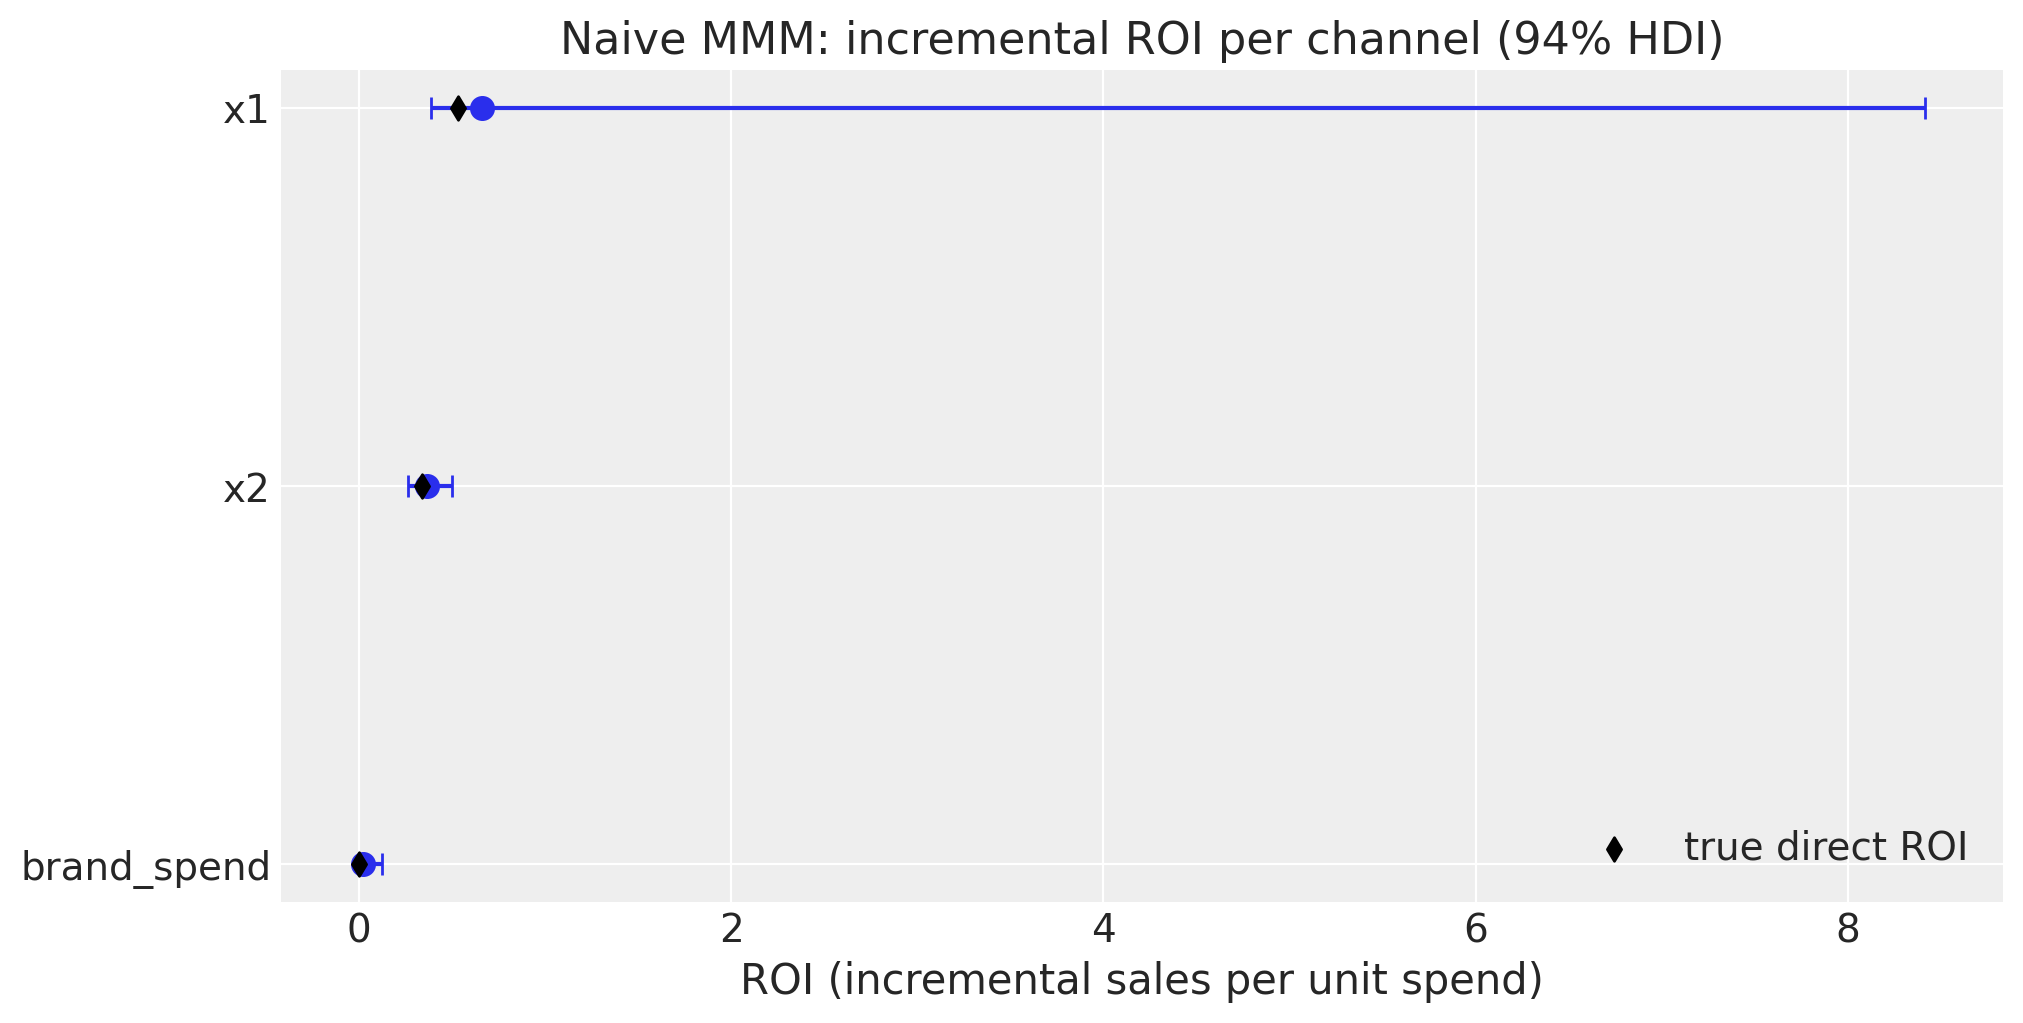

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(len(naive_channels))

for i, channel in enumerate(naive_channels):
    row = roi_naive_summary.loc[channel]
    ax.errorbar(
        row["median"],
        i,
        xerr=[[row["median"] - row["hdi_low"]], [row["hdi_high"] - row["median"]]],
        fmt="o",
        color="C0",
        capsize=4,
        markersize=8,
    )
ax.scatter(
    [true_roi_x1, true_roi_x2, 0.0],
    positions,
    color="black",
    marker="d",
    zorder=5,
    label="true direct ROI",
)
ax.set_yticks(positions, naive_channels)
ax.invert_yaxis()
ax.legend()
ax.set(
    title="Naive MMM: incremental ROI per channel (94% HDI)",
    xlabel="ROI (incremental sales per unit spend)",
);

The naive model gets the performance channels about right and reports an ROI of essentially zero for brand spend: with no short-term signal to latch onto, the brand response parameters simply collapse toward their priors and the channel's contribution to sales is negligible.

Here is the uncomfortable part: **the model is right**. The direct short-term effect of brand marketing *is* zero in our simulation. And yet this number is useless, and dangerous, as an answer to "what did the brand campaigns do for the business?", because the entire brand effect went into the time-varying intercept. If this ROI table were taken at face value, the brand budget would be cut. To answer the CMO's actual question we need to follow the effect into the baseline, which is what the two-stage workflow does.

## Stage 1: MMM with a Time-Varying Baseline

We now fit the measurement MMM with only the performance channels, exactly as the causal graph prescribes (brand spend has no direct edge to sales, and the naive model just confirmed it empirically). Excluding brand spend from Stage 1 also protects us from double counting when we credit brand through the baseline in Stage 2.

The time-varying intercept is a Hilbert Space Gaussian Process approximation, configured through {class}`~pymc_marketing.hsgp_kwargs.HSGPKwargs` as in {ref}`mmm_roas` and {ref}`mmm_tv_intercept`.

```{note}
The HSGP time-varying intercept is an *in-sample decomposition* device: out of sample it reverts to the prior mean. This workflow is therefore for measurement, not for forecasting the baseline. Anything else missing from the model (price changes, distribution, promotions) also lands in the baseline, so with real data make sure such drivers are either included as controls in Stage 1 or as variables in Stage 2, lest the VARX misattribute their effect to brand.
```

In [18]:
%%time
channels = ["x1", "x2"]
cost_share = xr.DataArray(
    df[channels].sum() / df[channels].sum().sum(),
    dims="channel",
)

model_config = {
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=2)),
    "gamma_fourier": Prior("Normal", mu=0, sigma=2, dims="fourier_mode"),
    "intercept_tvp_config": intercept_tvp_config,
    "adstock_alpha": Prior("Beta", alpha=2, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", alpha=2, beta=1, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=cost_share, dims="channel"),
}

mmm = MMM(
    date_column="date",
    target_column="y",
    channel_columns=channels,
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config=model_config,
)

X = df[["date", *channels]]

mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(
    var=["channel_contribution", "fourier_contribution", "intercept_contribution"]
)
_ = mmm.fit(X, y, **sampler_config)
_ = mmm.sample_posterior_predictive(
    X, extend_idata=True, combined=True, random_seed=rng
)

NUTS[nutpie]: [intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, y_sigma]


Output()

Output()

Sampling: [y]


Output()

CPU times: user 1min 29s, sys: 1.22 s, total: 1min 30s
Wall time: 25.5 s


In [19]:
az.diagnose(mmm.idata)

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
The following parameters has R-hat values greater than 1.01:
  intercept_latent_process_raw_ls
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizing your model with additional prior information or a more effective parameterization.


True

In [20]:
az.summary(
    mmm.idata,
    var_names=[
        "saturation_beta",
        "adstock_alpha",
        "saturation_lam",
        "intercept_baseline",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
saturation_beta[x1],0.44,0.23,0.19,0.88,2211,2335,1.00,0.0052,0.0059
saturation_beta[x2],0.223,0.145,0.087,0.5,3304,2962,1.00,0.0028,0.0035
adstock_alpha[x1],0.508,0.068,0.39,0.61,5126,3448,1.00,0.00094,0.00068
adstock_alpha[x2],0.215,0.087,0.084,0.36,3882,2909,1.00,0.0014,0.00098
saturation_lam[x1],1.41,0.73,0.51,2.8,2209,2497,1.00,0.015,0.012
saturation_lam[x2],1.52,0.91,0.43,3.2,3232,2447,1.00,0.015,0.014
intercept_baseline,0.6351,0.013,0.61,0.65,2855,2607,1.00,0.00025,0.00019


The decomposition below shows how the model splits sales between the performance channels and the evolving baseline.

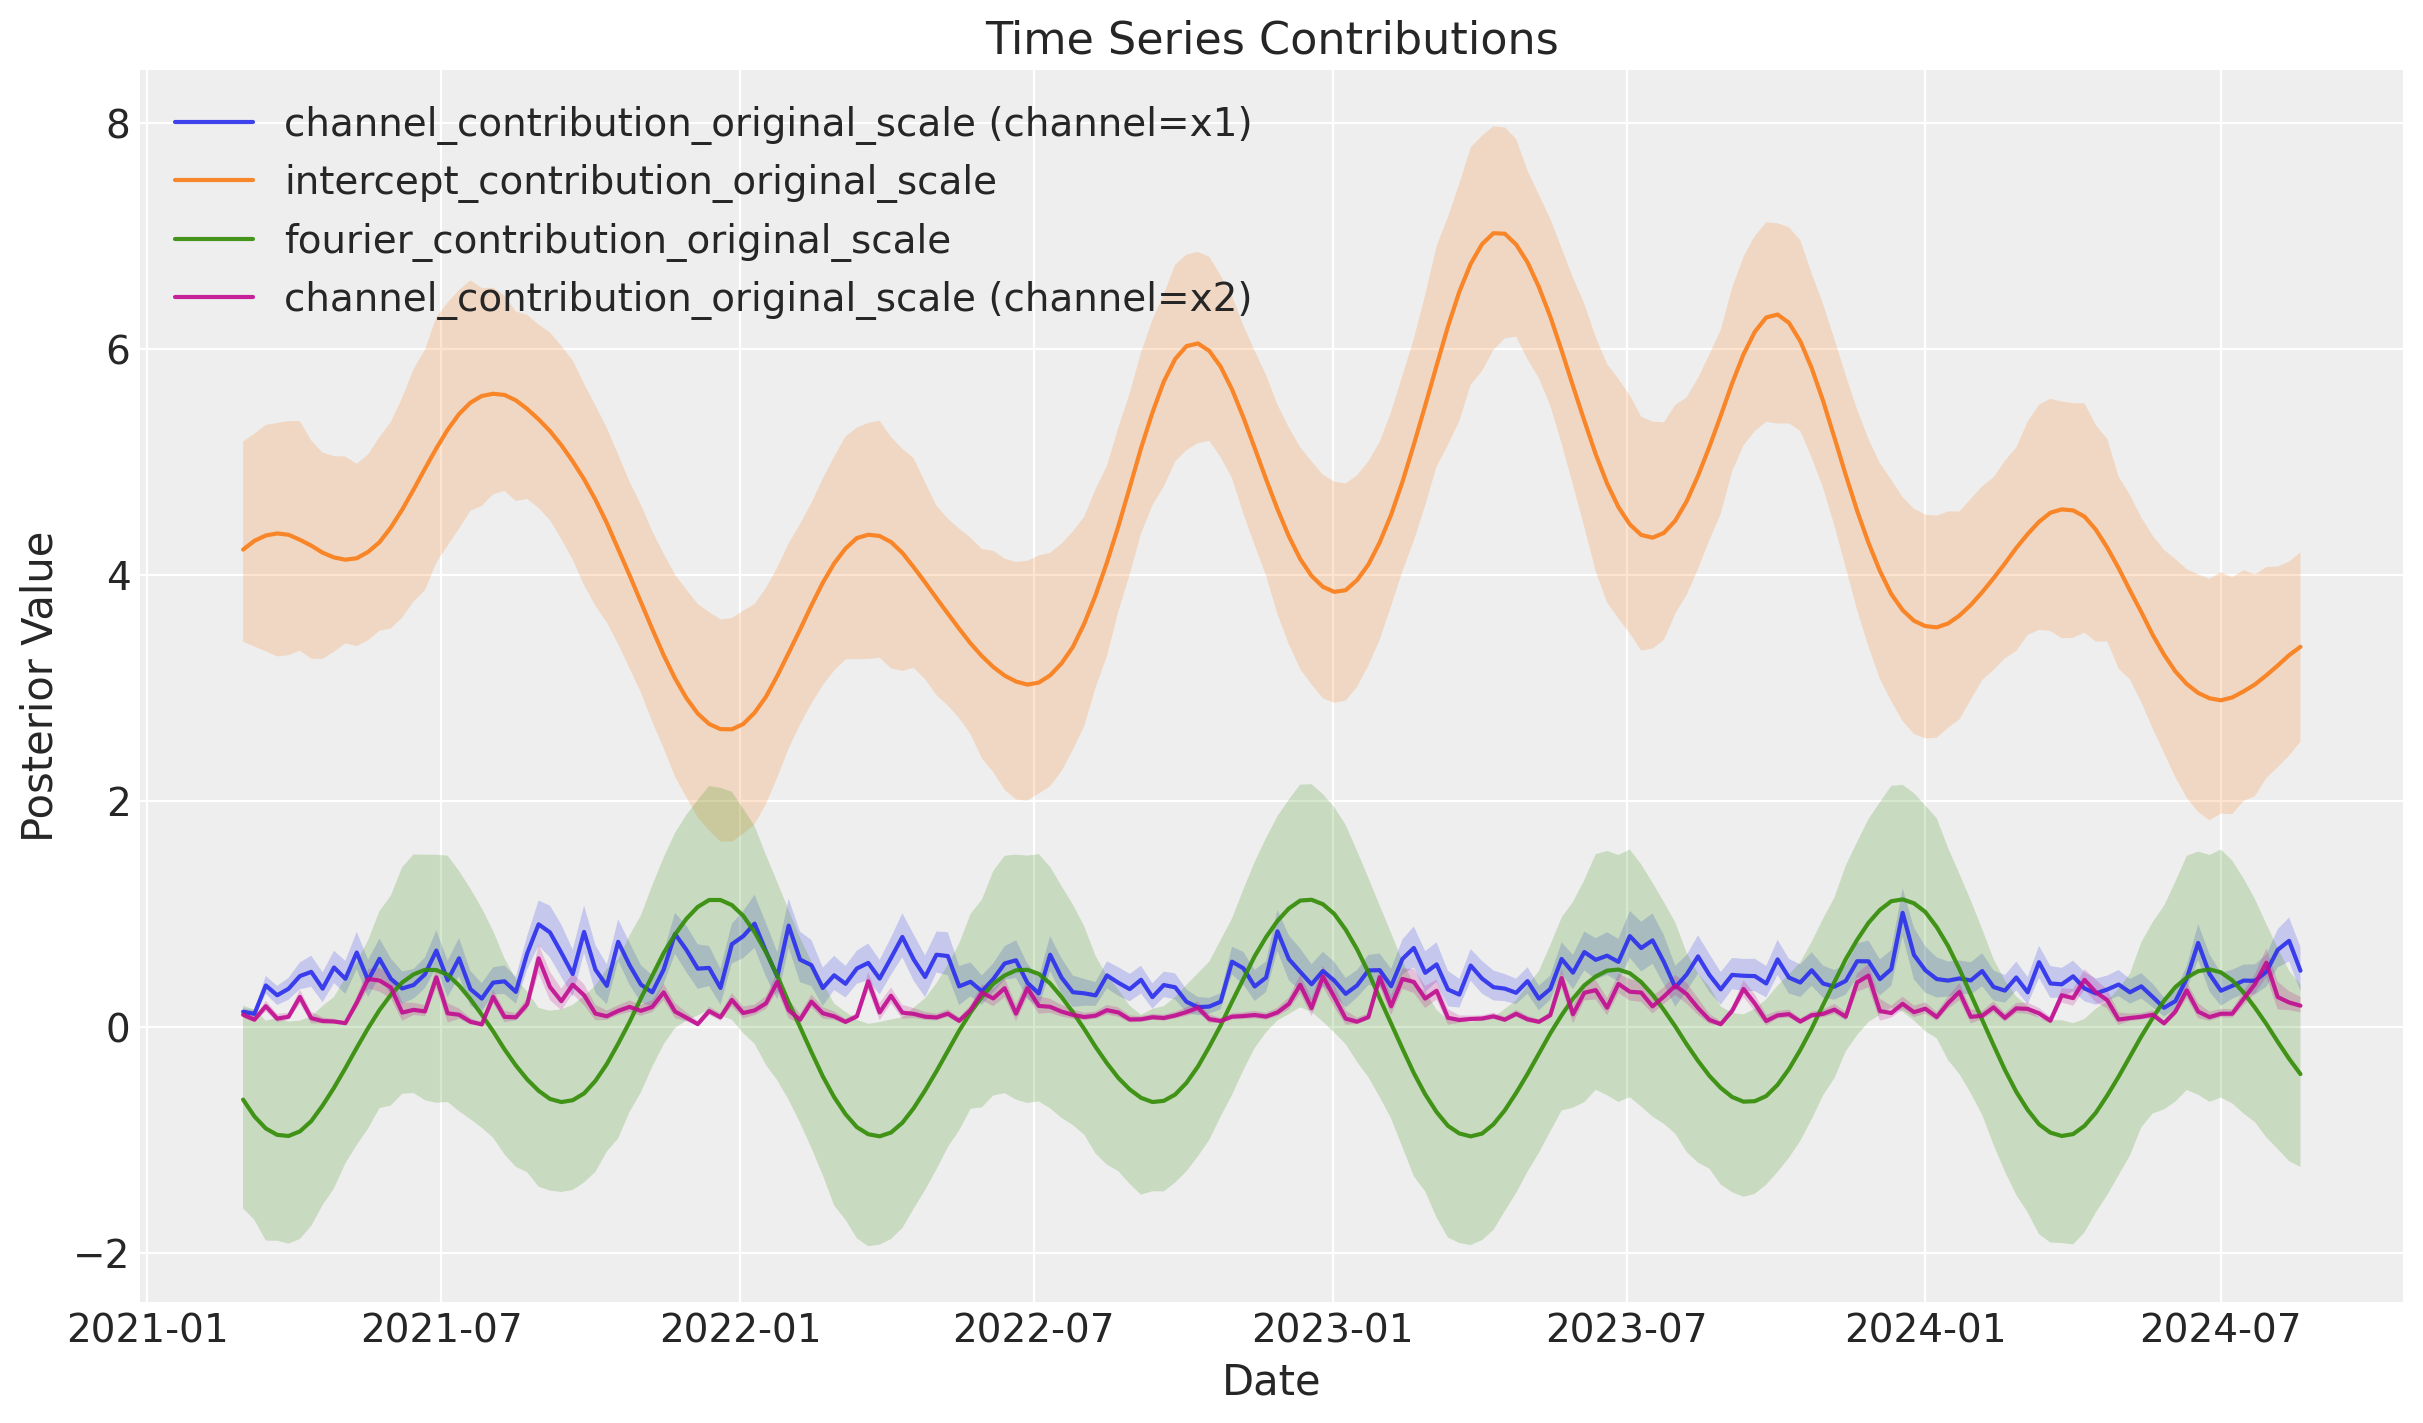

In [21]:
fig, axes = mmm.plot.contributions_over_time(
    var=[
        "channel_contribution_original_scale",
        "intercept_contribution_original_scale",
        "fourier_contribution_original_scale",
    ],
    dims={"channel": channels},
    combine_dims=True,
    hdi_prob=0.94,
    figsize=(12, 7),
)

The critical Stage-1 deliverable is the extracted baseline. Since we simulated the data, we can hold it against the true base sales path:

correlation(extracted baseline, true base sales) = 0.821


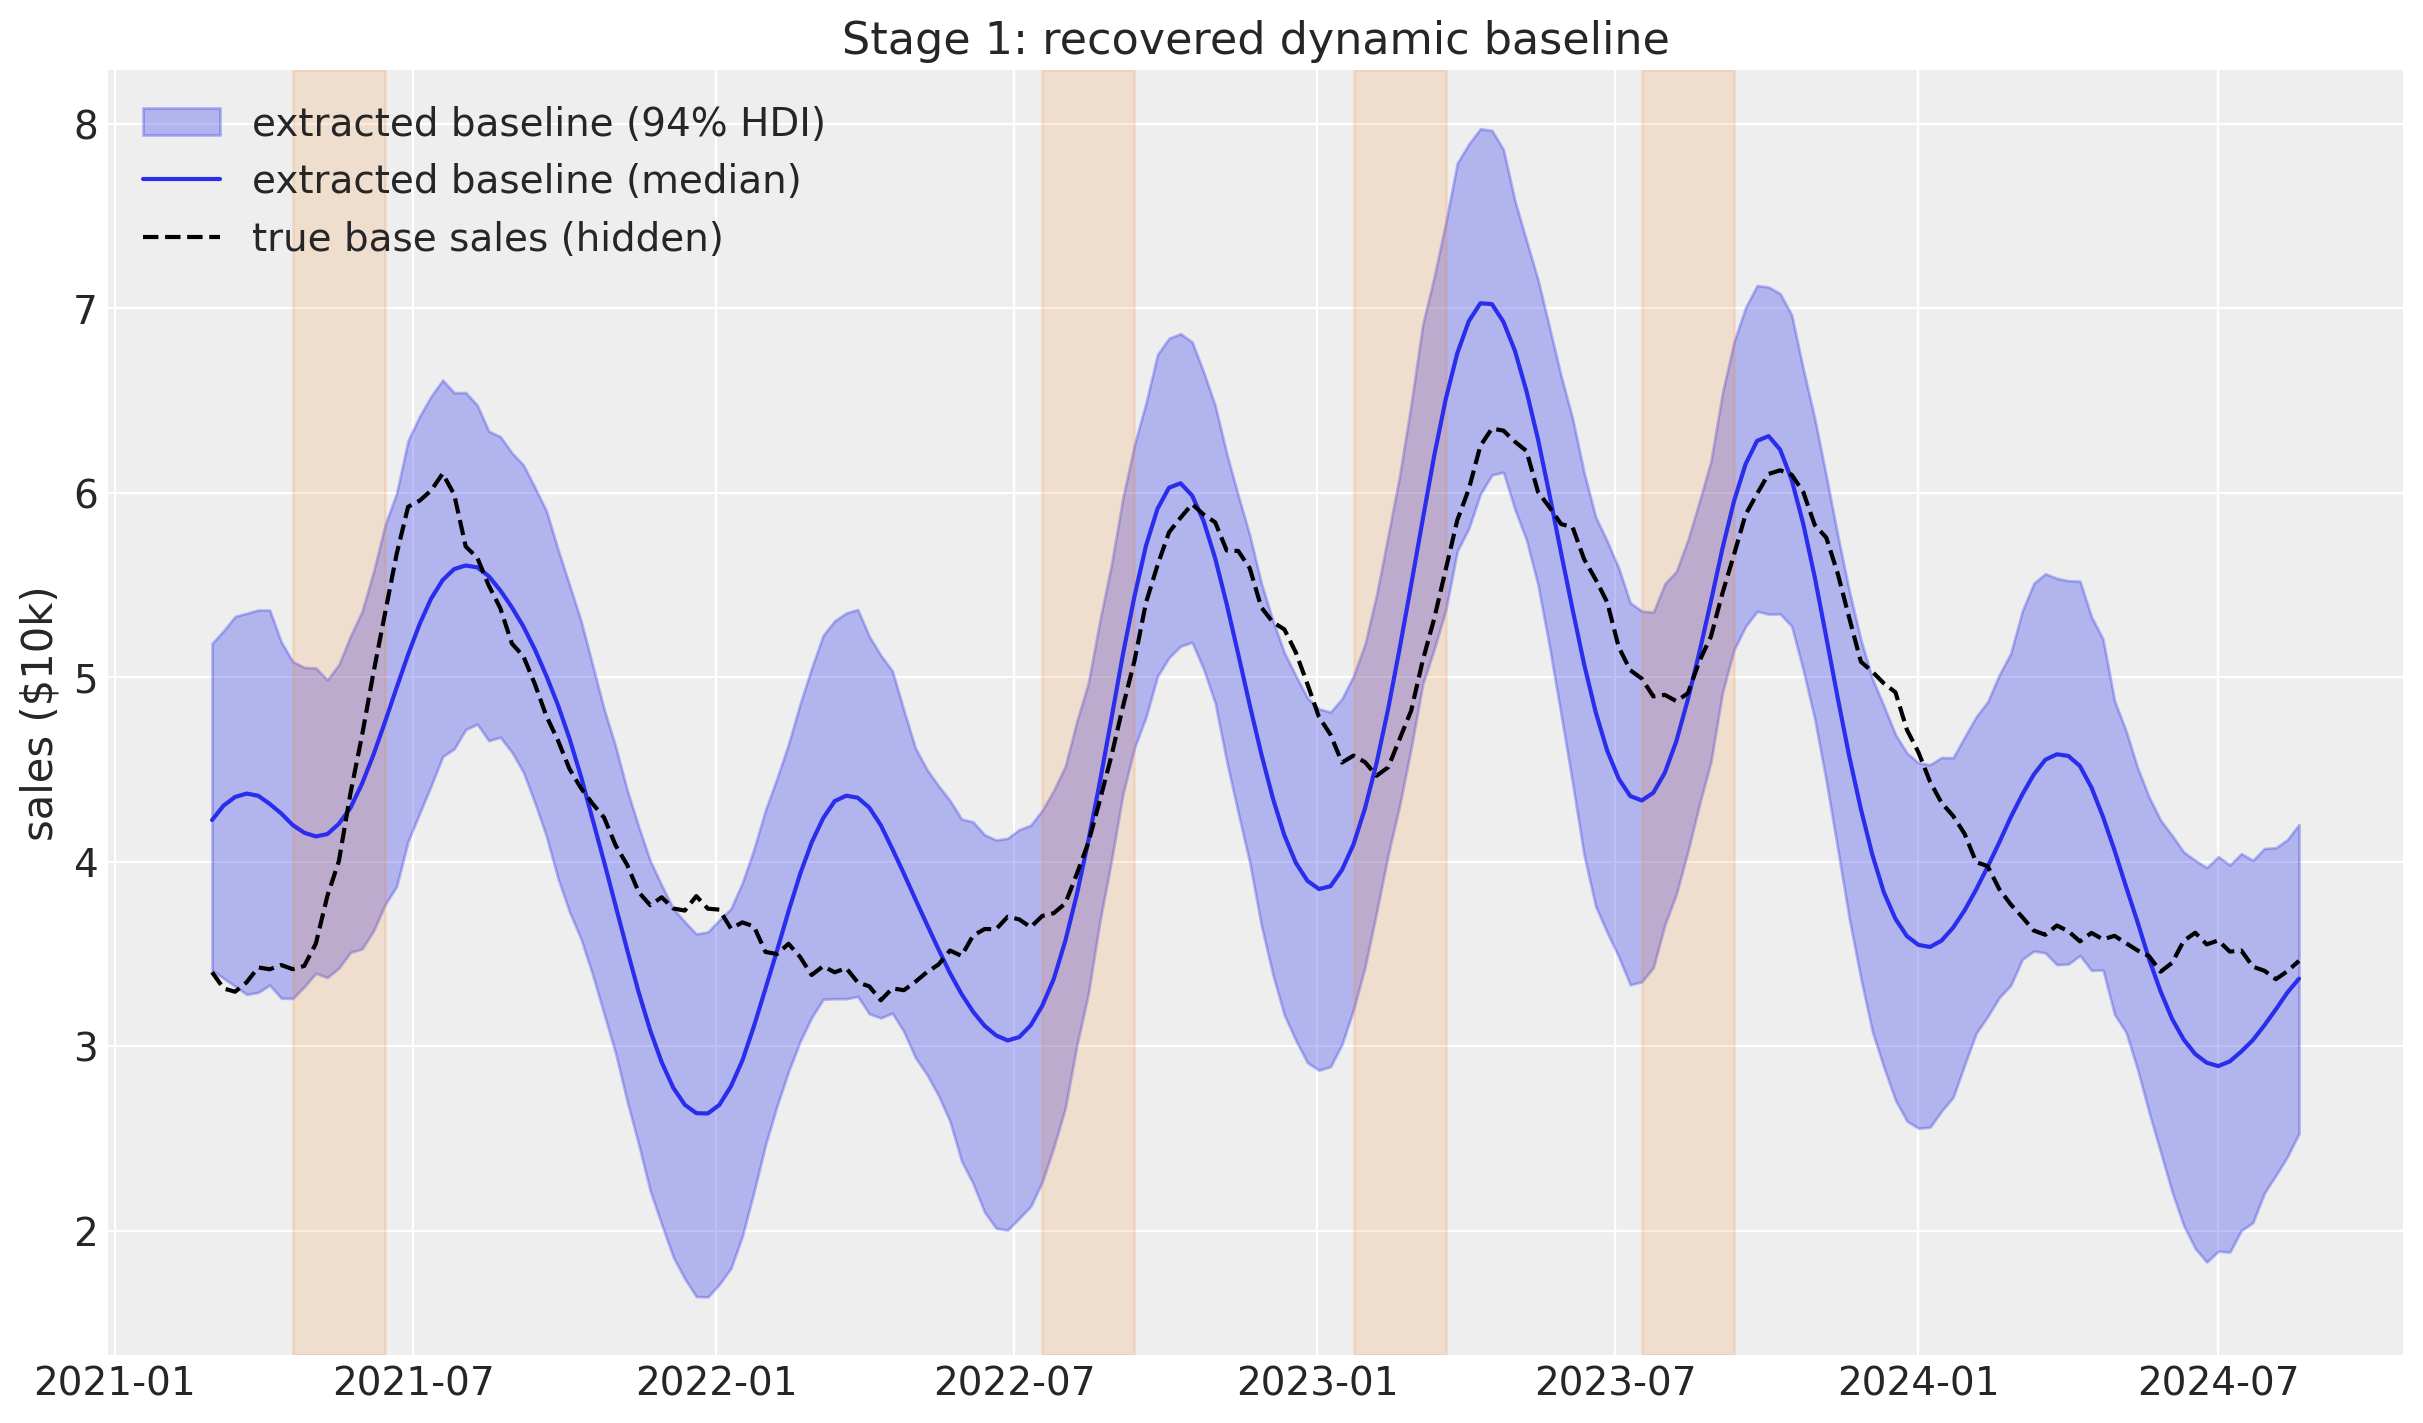

In [22]:
baseline_da = mmm.idata.posterior["intercept_contribution_original_scale"]
baseline_median = baseline_da.median(dim=("chain", "draw"))
baseline_hdi = az.hdi(baseline_da, prob=0.94)

fig, ax = plt.subplots()
ax.fill_between(
    df["date"],
    baseline_hdi.sel(ci_bound="lower"),
    baseline_hdi.sel(ci_bound="upper"),
    color="C0",
    alpha=0.3,
    label="extracted baseline (94% HDI)",
)
ax.plot(df["date"], baseline_median, color="C0", label="extracted baseline (median)")
ax.plot(
    truth_df["date"],
    truth_df["base_sales"],
    color="black",
    linestyle="--",
    label="true base sales (hidden)",
)
shade_flights(ax)
ax.legend(loc="upper left")
ax.set(title="Stage 1: recovered dynamic baseline", ylabel="sales ($10k)")

corr_baseline = np.corrcoef(baseline_median, truth_df["base_sales"])[0, 1]
print(f"correlation(extracted baseline, true base sales) = {corr_baseline:.3f}")

In [23]:
roi_stage1 = mmm.incrementality.contribution_over_spend(frequency="all_time").rename(
    "roi"
)
roi_stage1_hdi = az.hdi(roi_stage1, prob=0.94)

pd.DataFrame(
    {
        "recovered median": roi_stage1.median(dim=("chain", "draw")).to_series(),
        "hdi_low": roi_stage1_hdi.sel(ci_bound="lower").to_series(),
        "hdi_high": roi_stage1_hdi.sel(ci_bound="upper").to_series(),
        "true": [true_roi_x1, true_roi_x2],
    }
)

,recovered median,hdi_low,hdi_high,true
channel,,,,
x1,0.612955,0.433200,0.822270,0.529693
x2,0.358393,0.262269,0.476462,0.340416


The baseline tracks the true base sales closely (the wiggles are the price of a flexible GP, and some smoothing against the seasonal terms is expected), and the short-term ROIs match their true values. Stage 1 has done its job: the brand-driven drift is now an explicit, extractable time series instead of a nuisance.

## Stage 2 Preparation: the VARX Frame and Stationarity

Stage 2 models the joint dynamics of the extracted baseline and the two survey metrics, with brand spend as an exogenous input. We assemble the frame (impulso's {class}`~impulso.VARData` requires a `DatetimeIndex`) using the posterior median of the baseline; we will return to the uncertainty we discard by doing so in the last section.

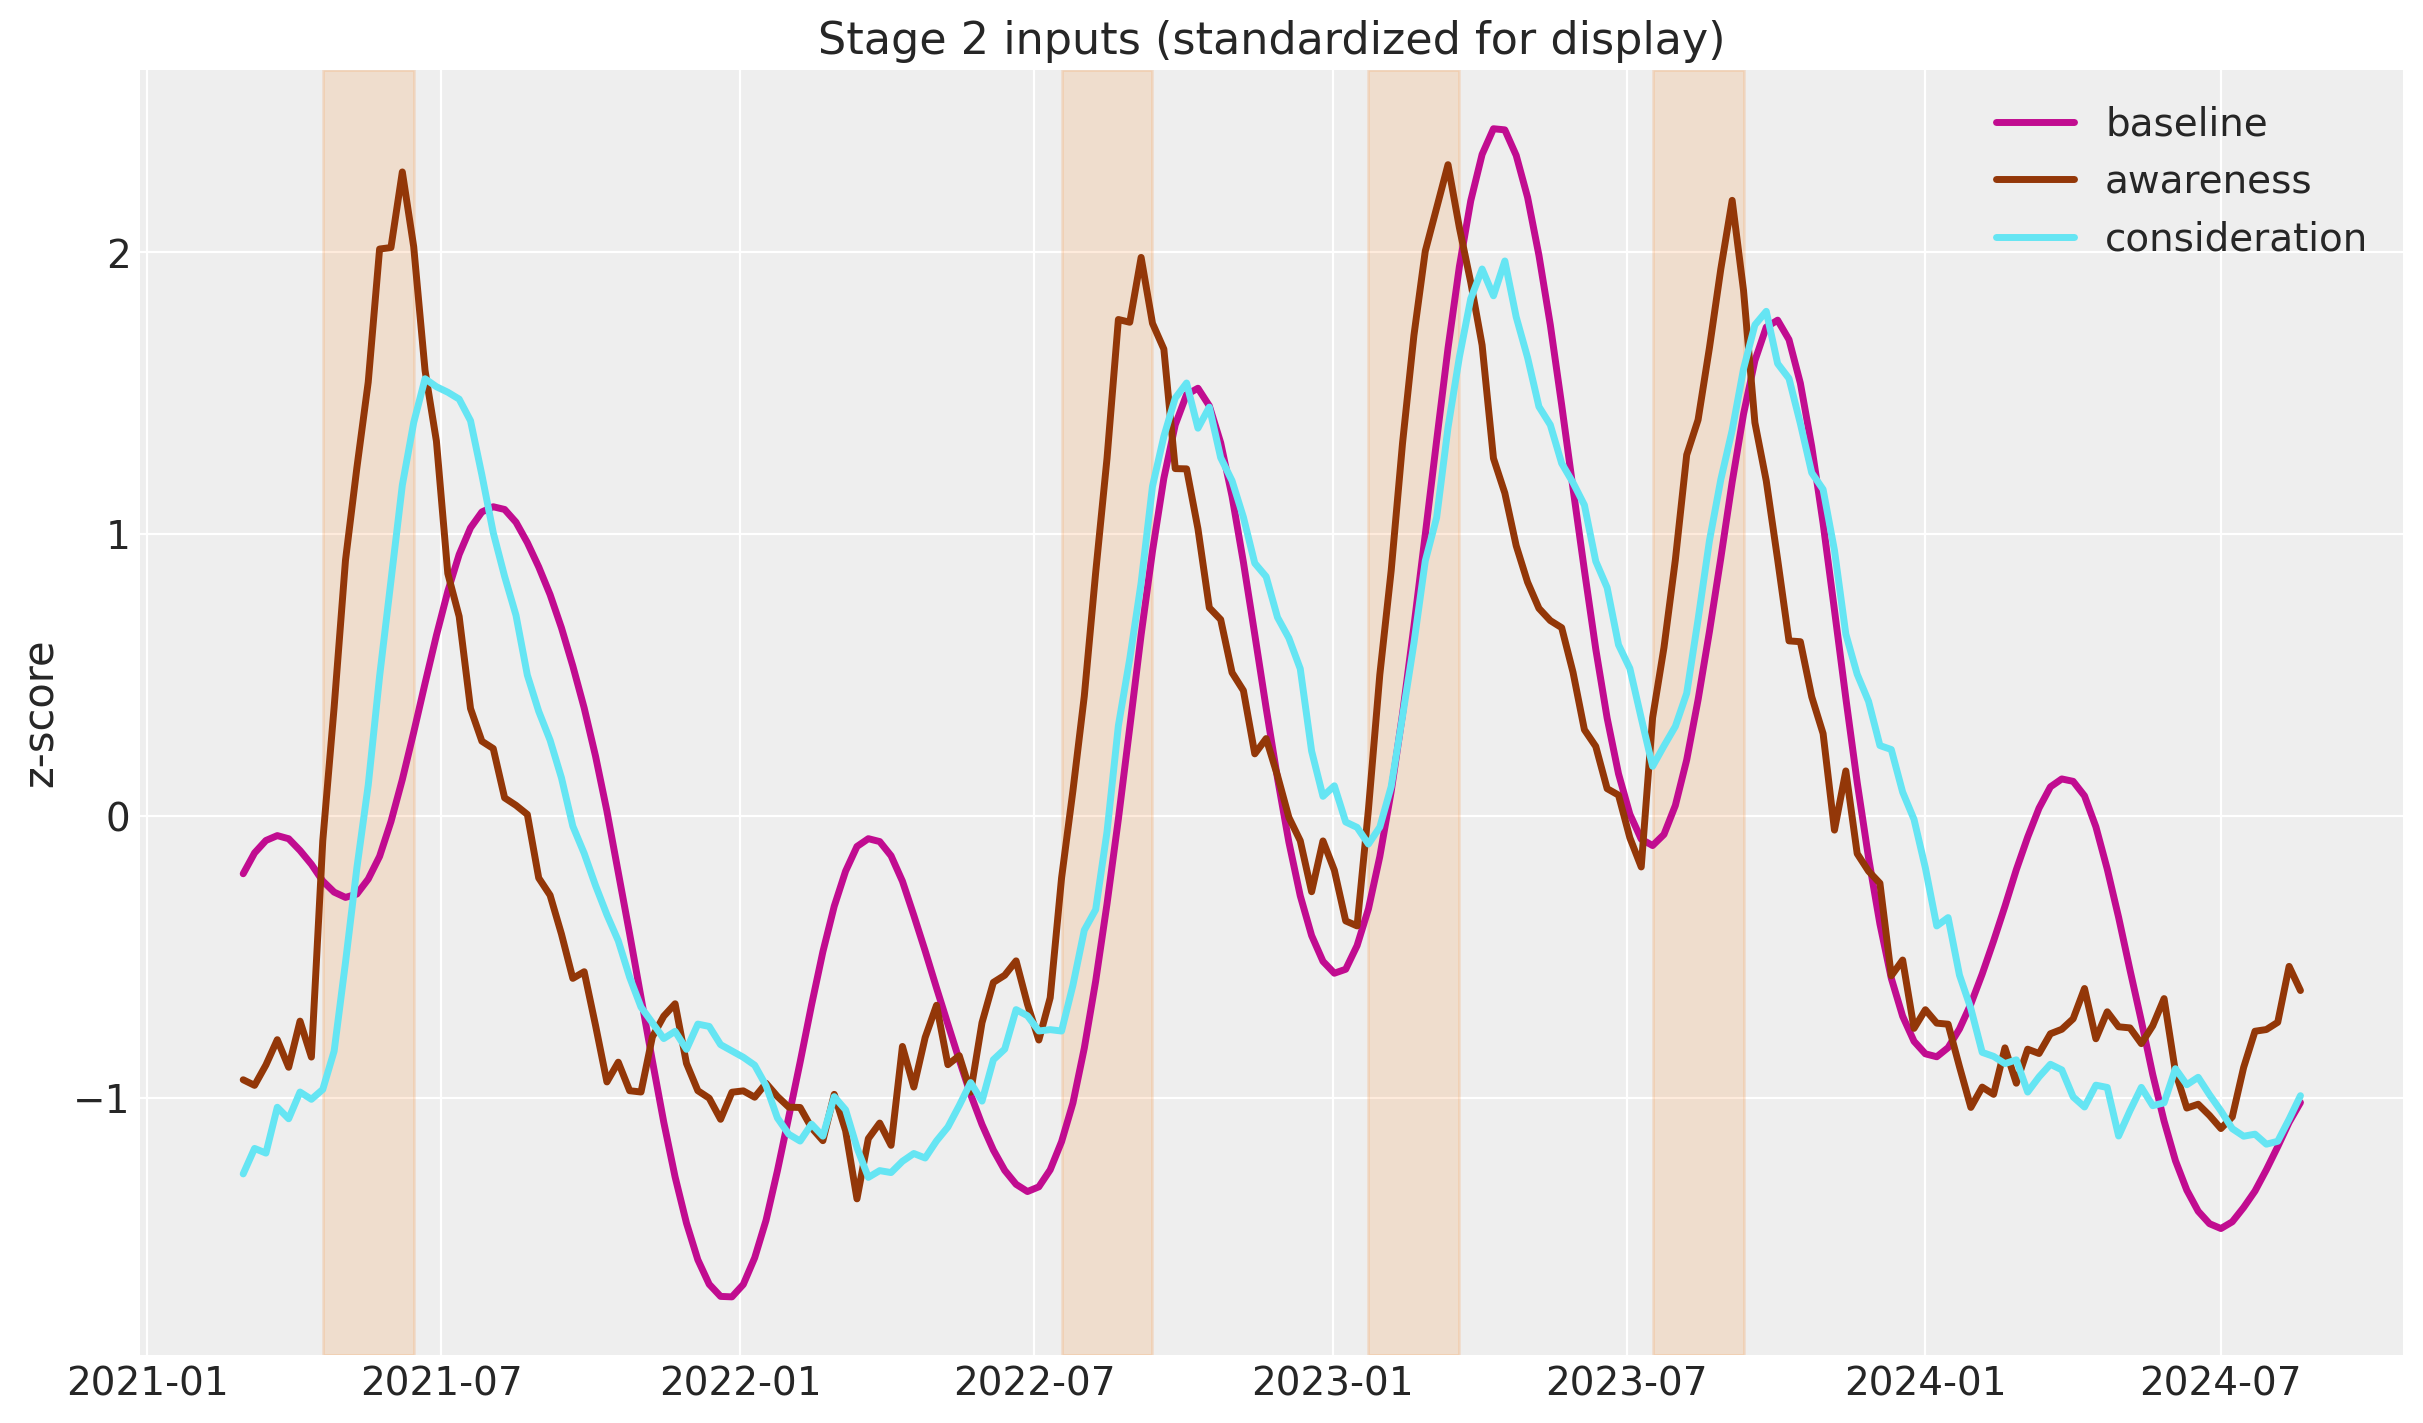

In [24]:
varx_df = pd.DataFrame(
    {
        "baseline": baseline_median.to_numpy(),
        "awareness": df["awareness"].to_numpy(),
        "consideration": df["consideration"].to_numpy(),
        "brand_spend": df["brand_spend"].to_numpy(),
    },
    index=pd.DatetimeIndex(df["date"], name="date"),
)

endog_vars = ["baseline", "awareness", "consideration"]

fig, ax = plt.subplots()
scaled = (varx_df[endog_vars] - varx_df[endog_vars].mean()) / varx_df[endog_vars].std()
for i, col in enumerate(endog_vars):
    ax.plot(varx_df.index, scaled[col], color=f"C{i + 3}", linewidth=2.5, label=col)

shade_flights(ax)
ax.legend(loc="upper right")
ax.set(
    title="Stage 2 inputs (standardized for display)",
    ylabel="z-score",
);

Awareness responds within each flight, consideration follows, and the baseline moves last: the funnel ordering is visible to the naked eye. Before fitting a VAR we check stationarity, since regressions among *integrated* (unit-root) series in levels can be spurious unless the series are cointegrated.

In [25]:
adf_test(varx_df, variables=endog_vars).table

,statistic,pvalue,lags,crit_1pct,crit_5pct,crit_10pct,reject,conclusion
variable,,,,,,,,
baseline,-1.178549,0.682755,13,-3.469886,-2.878903,-2.576027,False,non-stationary
awareness,-2.145728,0.226529,8,-3.468726,-2.878396,-2.575756,False,non-stationary
consideration,-2.514371,0.112017,6,-3.468280,-2.878202,-2.575653,False,non-stationary


In [26]:
kpss_test(varx_df, variables=endog_vars).table

,statistic,pvalue,lags,crit_1pct,crit_2_5pct,crit_5pct,crit_10pct,pvalue_bounded,reject,conclusion
variable,,,,,,,,,,
baseline,0.164983,0.1,9,0.739,0.574,0.463,0.347,True,False,stationary
awareness,0.175315,0.1,9,0.739,0.574,0.463,0.347,True,False,stationary
consideration,0.205504,0.1,9,0.739,0.574,0.463,0.347,True,False,stationary


In [27]:
johansen_test(varx_df[endog_vars]).table

,trace_stat,trace_crit,trace_reject,maxeig_stat,maxeig_crit,maxeig_reject
r,,,,,,
0,388.041607,29.7961,True,235.827134,21.1314,True
1,152.214473,15.4943,True,139.149495,14.2639,True
2,13.064978,3.8415,True,13.064978,3.8415,True


The verdicts are mixed, and that is realistic: every series in our simulation is stationary by construction (all autoregressive roots are below one), yet the ADF test fails to reject a unit root for the baseline and for consideration. Persistent-but-stationary series in a three-and-a-half-year sample routinely fool unit-root tests, and the ADF regression is in any case misspecified for series driven by an exogenous input like the flight schedule. The Johansen test is more informative here: it rejects at every rank, which means the system is best treated as full-rank stationary, so a **VAR in levels** is directly appropriate.

With real data, expect this ambiguity to be the rule. If the tests do point to integrated series linked by a cointegrating relationship, the textbook answer is a vector error correction model (VECM), which is exactly the road Cain (2022) takes; impulso does not currently ship a VECM, and a levels VAR with a Minnesota prior (which shrinks toward random-walk behavior) is a common pragmatic substitute under high persistence. What you should *not* do is difference the series, since differencing destroys the level relationships that the long-run multiplier is made of.

## Stage 2: Bayesian VARX with impulso

The model for the endogenous vector $z_t = (\text{baseline}_t, \text{awareness}_t, \text{consideration}_t)^\top$ is a one-lag VARX,

$$
z_t = a + A \, z_{t-1} + B_{\text{exog}} \, \text{brand}_t + \varepsilon_t,
\qquad \varepsilon_t \sim \text{MultivariateNormal}(0, \Sigma),
$$

with a Minnesota prior on the lag coefficients. Three features of this setup deserve emphasis:

- **No structural identification is needed.** For questions about shocks to *endogenous* variables a VAR needs identifying restrictions (Cholesky ordering, sign restrictions). Our question is about the *exogenous* input: brand spend is set by the planner's flight calendar, so the reduced-form coefficient $B_{\text{exog}}$ already has a causal interpretation, exactly as in {ref}`mmm_var_budget_optimization`.
- **Timing convention.** Brand spend enters contemporaneously, matching the data generating process where a flight lifts awareness within the same week.
- **Lag order: stay parsimonious.** Weekly funnel dynamics are well captured by a single lag, and every extra lag adds nine coefficients that must be pinned down by, effectively, four campaign flights. There is a subtler danger too: the baseline series carries Stage-1 estimation error, and information criteria respond to that noise by demanding *more* lags (on this data BIC asks for four), which then dilute the brand transmission across a long lag polynomial and bias the long-run multiplier downward. Use information criteria as a starting point with real data, but prefer the smallest lag order compatible with the dynamics you believe in, and check robustness to the choice.

We keep the default nearly-flat prior scale on $B_{\text{exog}}$: shrinking the exogenous coefficients toward zero would bias the very effect we are trying to measure.

In [28]:
%%time
var_data = VARData.from_df(varx_df, endog=endog_vars, exog=["brand_spend"])

varx = VAR(lags=1, prior="minnesota")
fitted = varx.fit(
    var_data,
    sampler=NUTSSampler(
        nuts_sampler="nutpie",
        draws=1_000,
        tune=1_000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed=seed + 1,
    ),
)

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

CPU times: user 13.8 s, sys: 364 ms, total: 14.2 s
Wall time: 5.27 s


In [29]:
az.diagnose(fitted.idata)

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


False

In [30]:
az.summary(fitted.idata, var_names=["B_exog"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"B_exog[baseline, brand_spend]",0.1362,0.0327,0.083,0.19,4468,3056,1.00,0.00049,0.00035
"B_exog[awareness, brand_spend]",0.2554,0.015,0.23,0.28,3449,3288,1.00,0.00026,0.00018
"B_exog[consideration, brand_spend]",0.0347,0.0135,0.013,0.056,3141,2986,1.00,0.00024,0.00016


The posterior on $B_{\text{exog}}$ already shows the funnel at work: brand spend moves awareness contemporaneously and has no meaningful same-week effect on consideration or the baseline. The long-term story lives in the *dynamic multiplier*

$$
\Psi_h = \Phi_h B_{\text{exog}}, \qquad h = 0, 1, 2, \dots
$$

where $\Phi_h$ are the moving-average matrices of the fitted VAR. $\Psi_h$ answers: if we spend one extra unit on brand this week, how much do the baseline, awareness and consideration move $h$ weeks from now? We compute it for every posterior draw with impulso's `lag_matrices` and `compute_ma_phi` helpers and accumulate over the horizon.

In [31]:
def dynamic_multiplier(fitted_var, horizon):
    posterior = fitted_var.idata.posterior
    b_draws = posterior["B"].transpose("chain", "draw", "var", "coeff").values
    b_exog_draws = posterior["B_exog"].transpose("chain", "draw", "var", "exog").values

    phi = compute_ma_phi(
        lag_matrices(b_draws, n_lags=fitted_var.n_lags), horizon=horizon
    )
    impulse = phi @ b_exog_draws[:, :, np.newaxis, :, :]
    return xr.DataArray(
        impulse,
        dims=("chain", "draw", "horizon", "response", "exog"),
        coords={
            "horizon": np.arange(horizon + 1),
            "response": list(fitted_var.var_names),
            "exog": ["brand_spend"],
        },
        name="dynamic_multiplier",
    )


theta = dynamic_multiplier(fitted, horizon=horizon)
cum_multiplier = theta.cumsum("horizon")

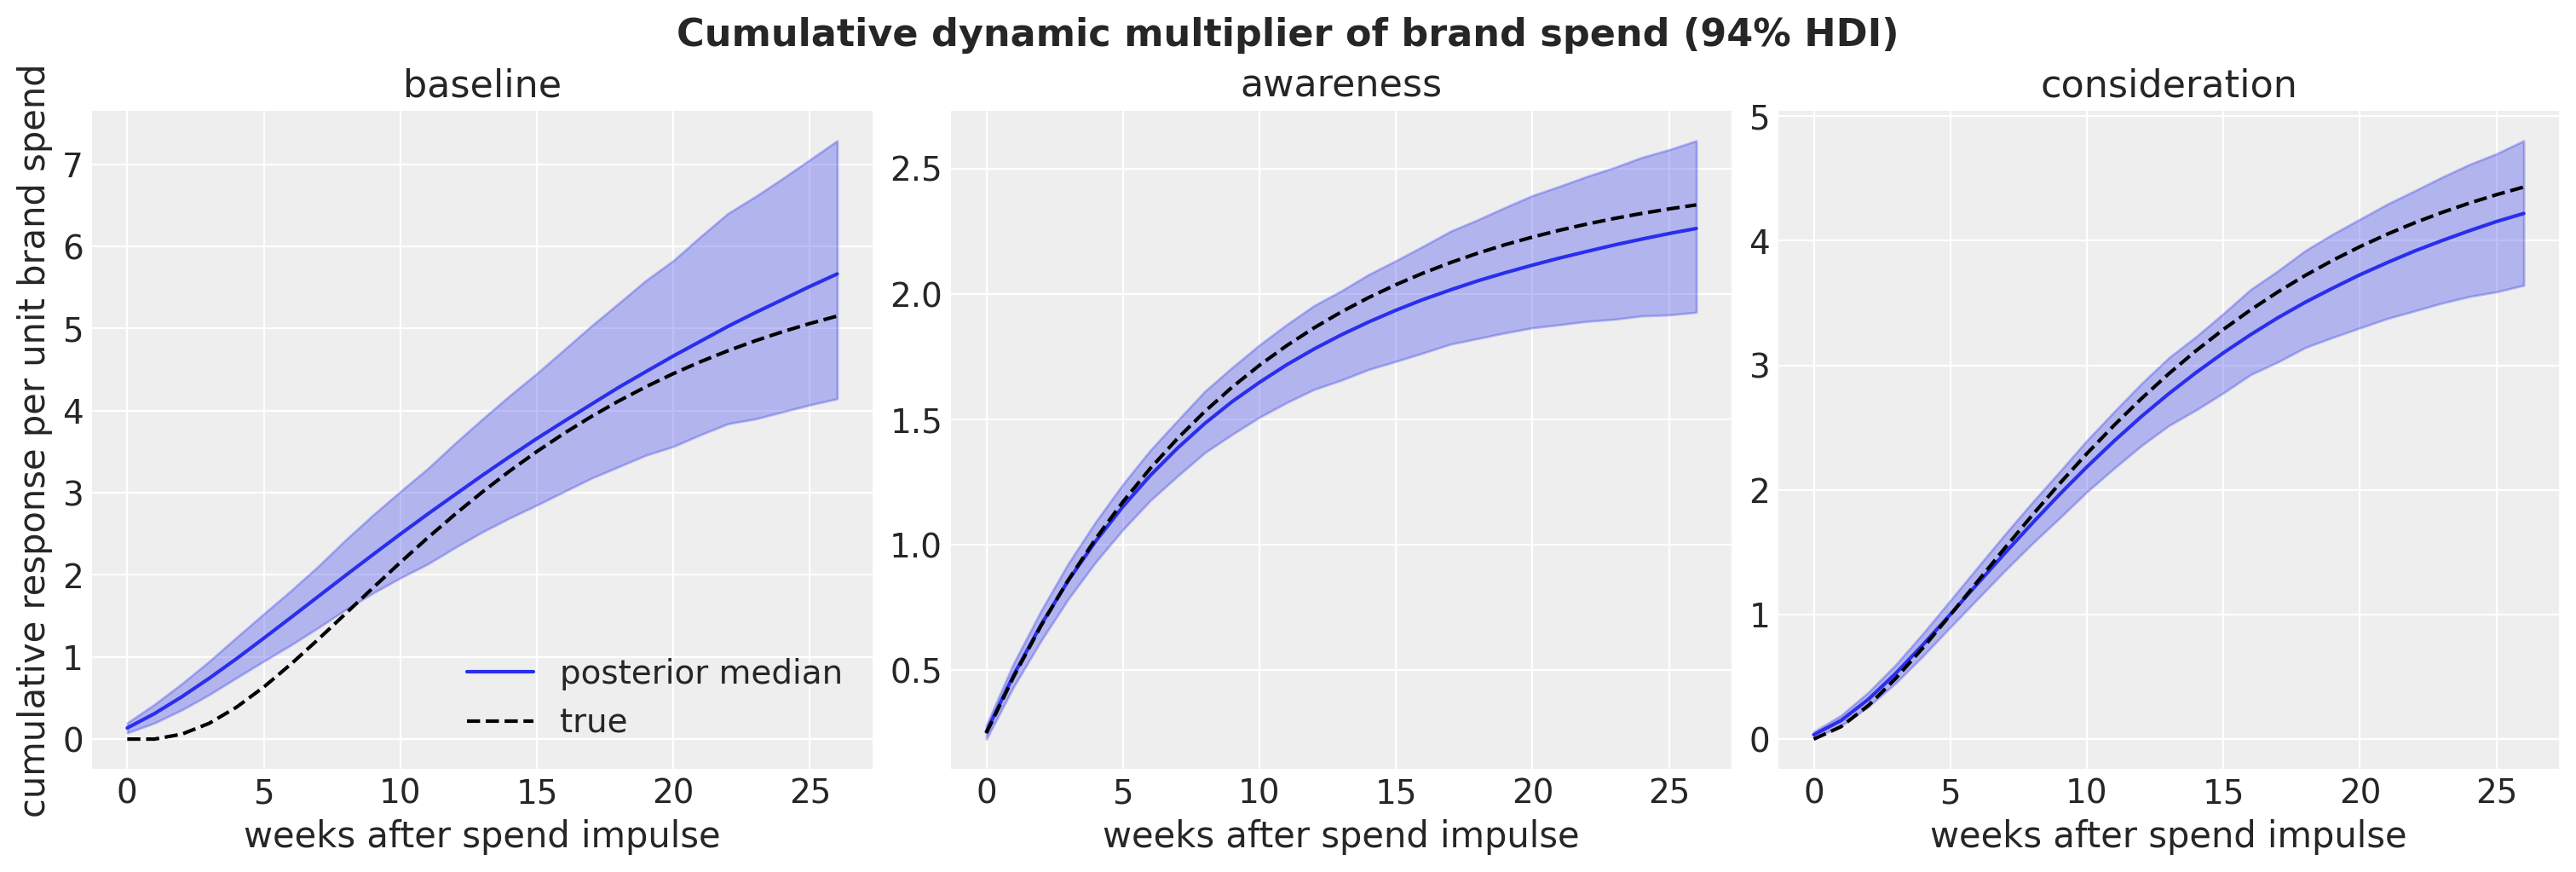

In [32]:
true_curves = {
    "baseline": np.cumsum(impulse_b),
    "awareness": np.cumsum(impulse_a),
    "consideration": np.cumsum(impulse_c),
}

fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 5), sharex=True, layout="constrained"
)
for ax, response in zip(axes, ["baseline", "awareness", "consideration"], strict=True):
    curve = cum_multiplier.sel(response=response, exog="brand_spend")
    median = curve.median(dim=("chain", "draw"))
    hdi = az.hdi(curve, prob=0.94)
    ax.fill_between(
        curve["horizon"],
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        alpha=0.3,
        color="C0",
    )
    ax.plot(curve["horizon"], median, color="C0", label="posterior median")
    ax.plot(
        curve["horizon"],
        true_curves[response],
        color="black",
        linestyle="--",
        label="true",
    )
    ax.set(title=response, xlabel="weeks after spend impulse")
axes[0].set(ylabel="cumulative response per unit brand spend")
axes[0].legend(loc="lower right")
fig.suptitle(
    "Cumulative dynamic multiplier of brand spend (94% HDI)",
    fontsize=16,
    fontweight="bold",
);

The recovered multiplier tracks the truth for all three responses, and the true curve lies inside the 94% credible band throughout. This is the notebook's centerpiece: the two-stage workflow has recovered the long-run causal effect of brand spend on base sales, an effect that is *completely invisible* to the naive MMM.

## Total Effect and ROI Decomposition

Two related but distinct quantities can now be reported, and it is worth being pedantic about the difference:

1. **Forward-looking brand ROI.** The cumulative multiplier at $h = 26$ is the incremental base sales generated within 26 weeks per incremental unit of brand spend. This is the decision-relevant number for planning the next campaign. It deliberately truncates the tail (about 14% of the effect in our simulation).
2. **In-sample brand contribution.** For a decomposition of *observed, historical* sales we convolve the actual spend path with the per-week multiplier, crediting each week of spend with its response over the following 26 weeks. Note the two disciplines this imposes: we do not simply multiply total spend by the cumulative multiplier (each flight only pays out what the calendar allows before the sample ends), and we do not extrapolate the fitted VAR beyond the 26-week window, where posterior draws with near-unit persistence would compound into fragile long-tail credit.

In [33]:
roi_brand_draws = cum_multiplier.sel(
    response="baseline", exog="brand_spend", horizon=horizon
)
roi_brand_median = float(roi_brand_draws.median())
roi_brand_hdi = az.hdi(roi_brand_draws, prob=0.94)

print(
    f"two-stage brand ROI ({horizon}-week window): "
    f"{roi_brand_median:.2f} "
    f"[{float(roi_brand_hdi.sel(ci_bound='lower')):.2f}, "
    f"{float(roi_brand_hdi.sel(ci_bound='upper')):.2f}] "
    f"(truth: {true_long_term_roi:.2f})"
)

two-stage brand ROI (26-week window): 5.66 [4.15, 7.29] (truth: 5.15)


In [34]:
theta_base = theta.sel(response="baseline", exog="brand_spend").values

spend_path = df["brand_spend"].to_numpy()
brand_contribution_draws = np.zeros((*theta_base.shape[:2], n_obs))
for h in range(horizon + 1):
    brand_contribution_draws[:, :, h:] += (
        theta_base[:, :, h][:, :, None] * spend_path[None, None, : n_obs - h]
    )

brand_contribution = xr.DataArray(
    brand_contribution_draws,
    dims=("chain", "draw", "date"),
    coords={"date": df["date"]},
    name="brand_contribution",
)
brand_contribution_median = brand_contribution.median(dim=("chain", "draw"))

total_brand_uplift = float(brand_contribution_median.sum())
print(
    f"in-sample brand uplift within the {horizon}-week window: {total_brand_uplift:.1f} ($10k)"
)
print(f"total brand spend: {spend_path.sum():.1f} ($10k)")

in-sample brand uplift within the 26-week window: 183.4 ($10k)
total brand spend: 32.4 ($10k)


The punchline table compares the three views of ROI for every spend line. For the performance channels the two-stage estimate is just the Stage-1 short-term ROI. For brand, the naive estimate is the direct effect (zero by construction) while the two-stage estimate is the 26-week dynamic multiplier.

In [35]:
def fmt(median, low, high):
    return f"{median:.2f} [{low:.2f}, {high:.2f}]"


def roi_row(da, channel):
    sel = da.sel(channel=channel)
    hdi = az.hdi(sel, prob=0.94)
    return fmt(
        float(sel.median()),
        float(hdi.sel(ci_bound="lower")),
        float(hdi.sel(ci_bound="upper")),
    )


summary_table = pd.DataFrame(
    {
        "naive MMM ROI": [
            roi_row(roi_naive, "x1"),
            roi_row(roi_naive, "x2"),
            roi_row(roi_naive, "brand_spend"),
        ],
        "two-stage ROI": [
            roi_row(roi_stage1, "x1"),
            roi_row(roi_stage1, "x2"),
            fmt(
                roi_brand_median,
                float(roi_brand_hdi.sel(ci_bound="lower")),
                float(roi_brand_hdi.sel(ci_bound="upper")),
            ),
        ],
        "true ROI": [
            f"{true_roi_x1:.2f}",
            f"{true_roi_x2:.2f}",
            f"{true_long_term_roi:.2f}",
        ],
    },
    index=["x1", "x2", "brand"],
)
summary_table

,naive MMM ROI,two-stage ROI,true ROI
x1,"0.66 [0.39, 8.41]","0.61 [0.43, 0.82]",0.53
x2,"0.37 [0.26, 0.50]","0.36 [0.26, 0.48]",0.34
brand,"0.02 [0.00, 0.12]","5.66 [4.15, 7.29]",5.15


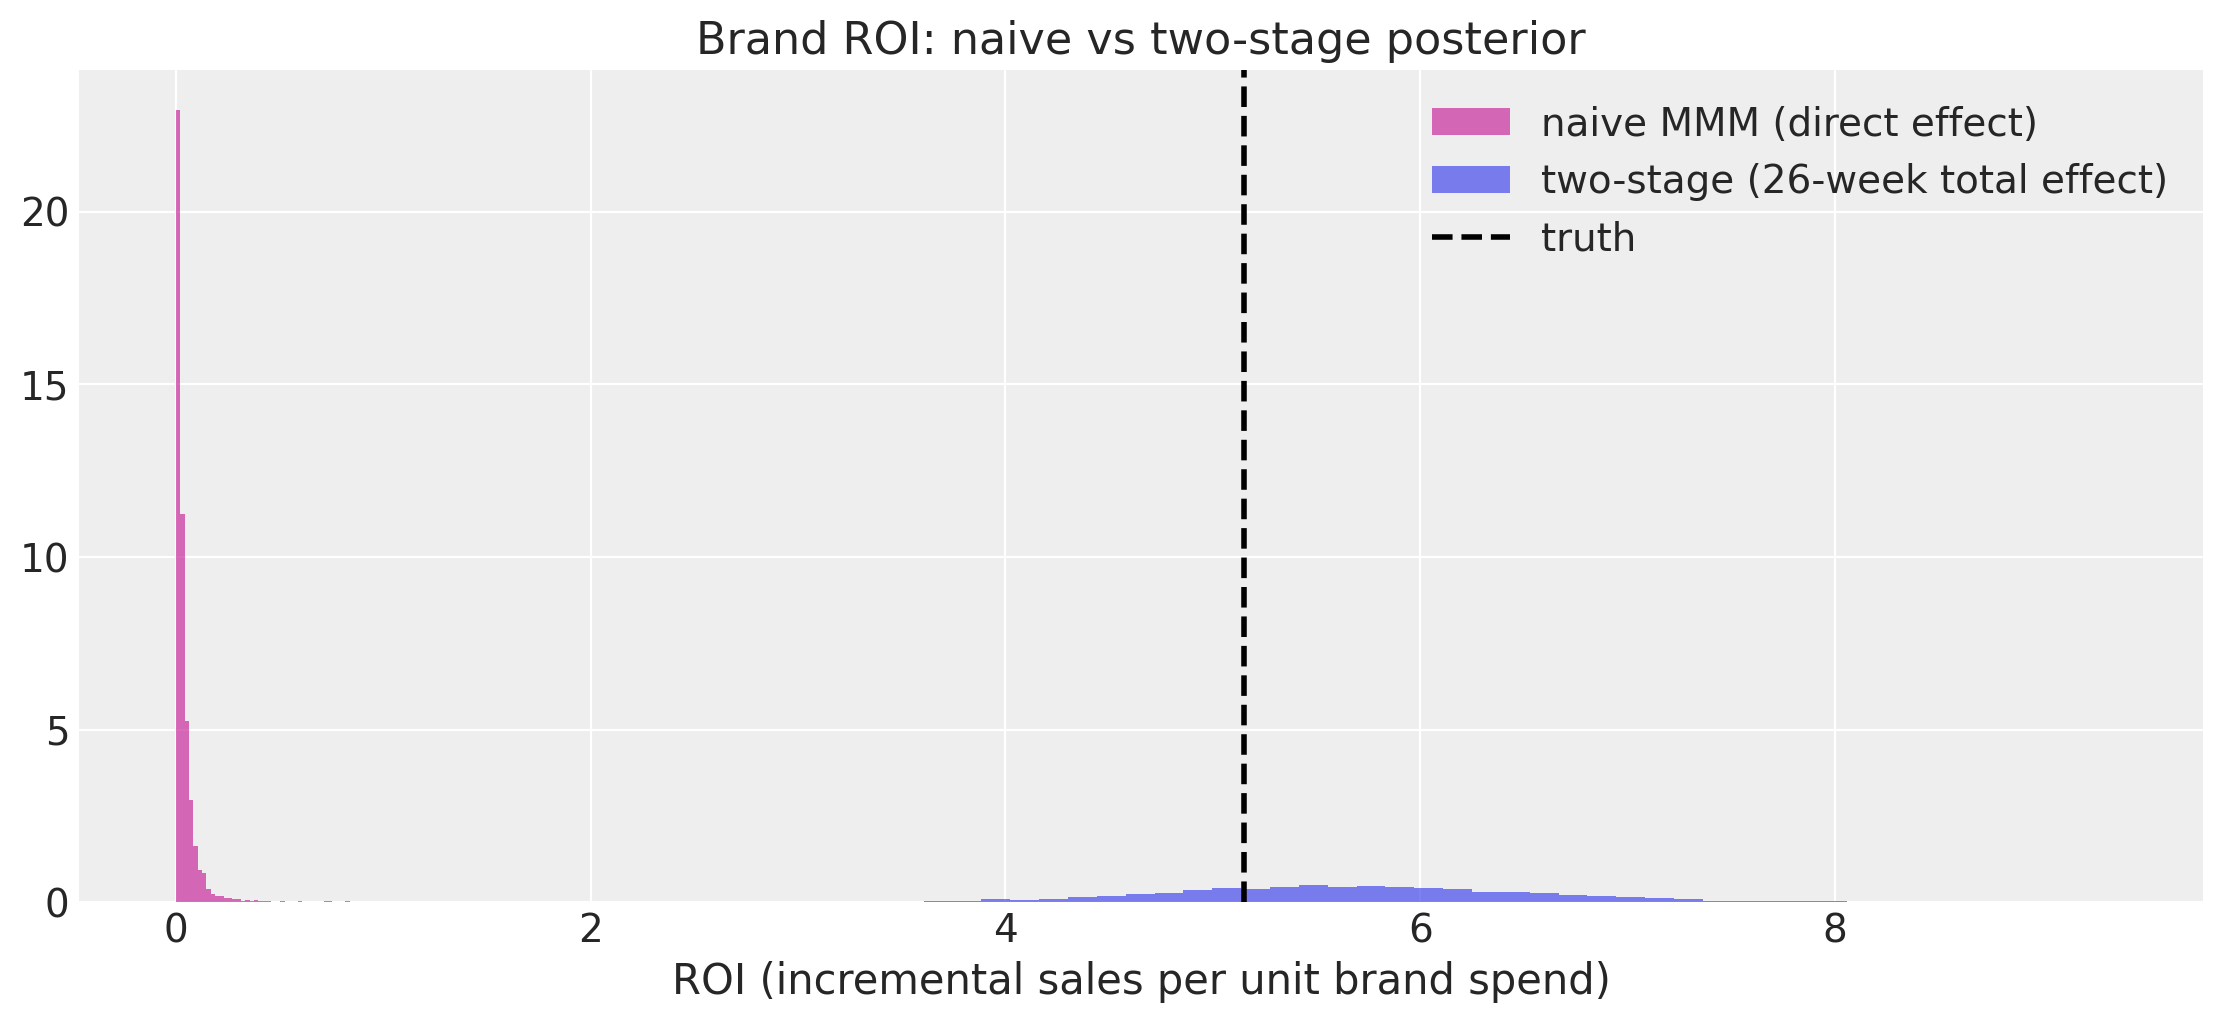

In [36]:
naive_brand_draws = roi_naive.sel(channel="brand_spend")

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    naive_brand_draws.values.flatten(),
    bins=50,
    density=True,
    alpha=0.6,
    color="C3",
    label="naive MMM (direct effect)",
)
ax.hist(
    roi_brand_draws.values.flatten(),
    bins=50,
    density=True,
    alpha=0.6,
    color="C0",
    label="two-stage (26-week total effect)",
)
ax.axvline(
    true_long_term_roi, color="black", linestyle="--", linewidth=2, label="truth"
)
ax.legend()
ax.set(
    title="Brand ROI: naive vs two-stage posterior",
    xlabel="ROI (incremental sales per unit brand spend)",
);

Finally, the in-sample decomposition. We stack the steady baseline (the extracted baseline minus the brand-driven part), the brand uplift, and the short-term channel contributions; the remaining gap to observed sales is seasonality plus noise.

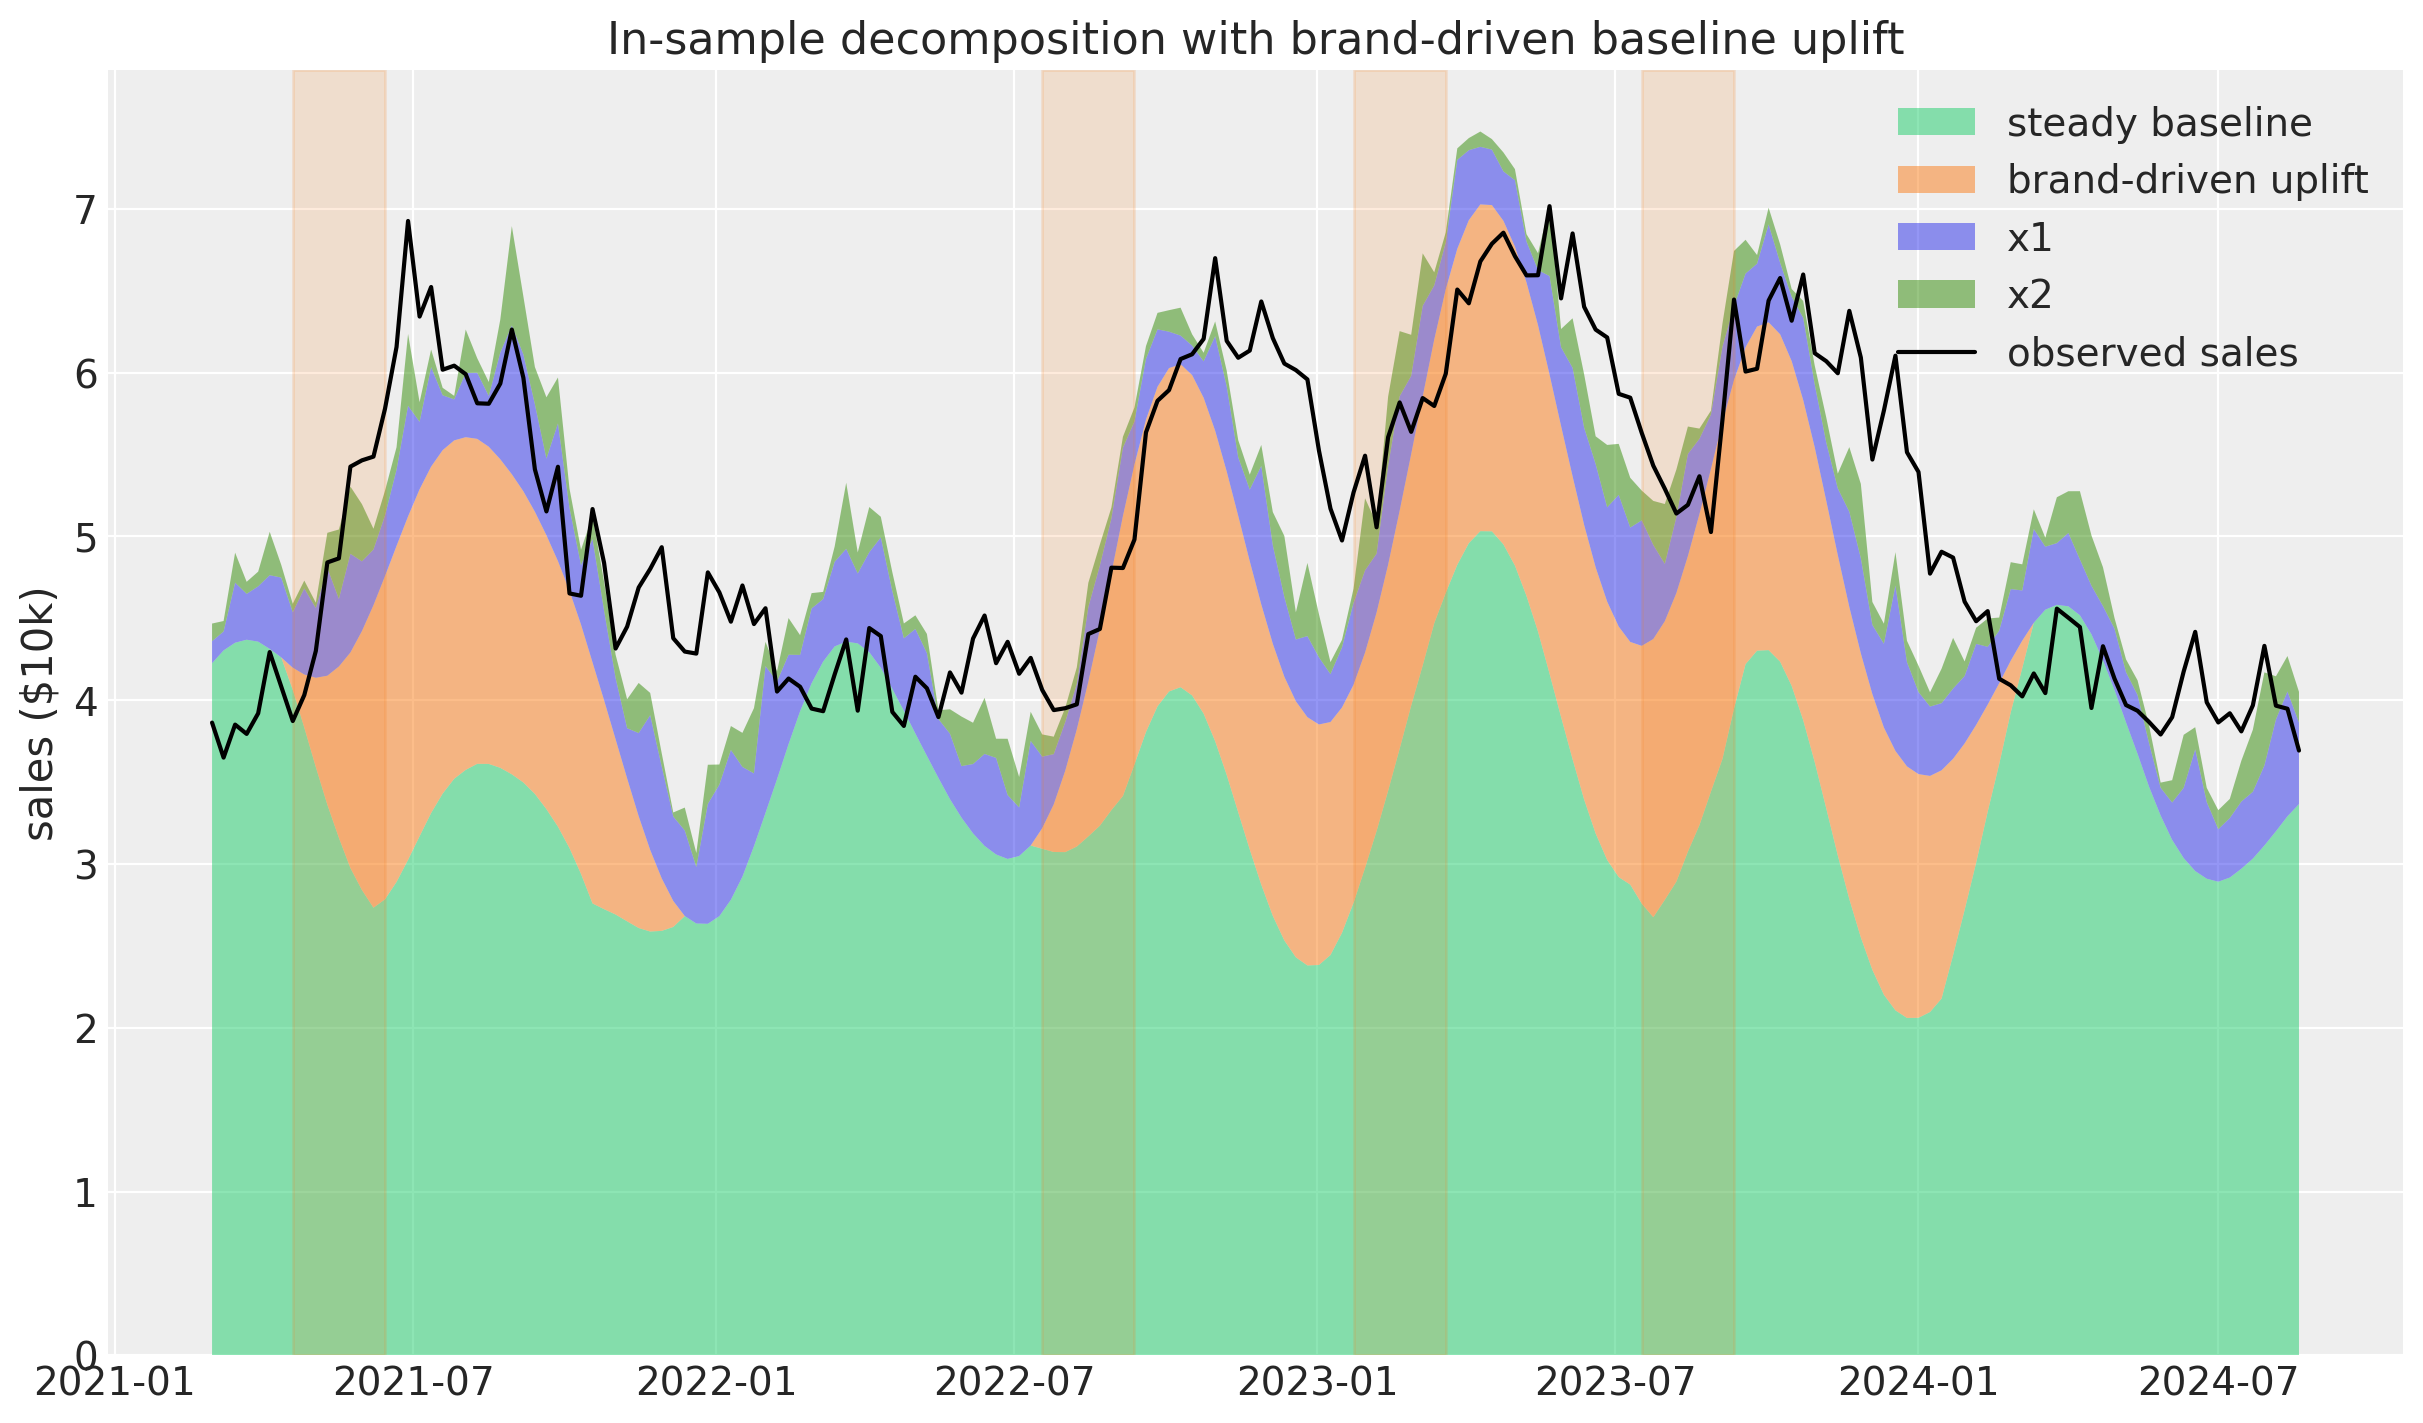

In [37]:
channel_contribution_median = (
    mmm.idata.posterior["channel_contribution_original_scale"]
    .median(dim=("chain", "draw"))
    .to_numpy()
)
steady_baseline = baseline_median.to_numpy() - brand_contribution_median.to_numpy()

components = np.vstack(
    [
        steady_baseline,
        brand_contribution_median.to_numpy(),
        channel_contribution_median[:, 0],
        channel_contribution_median[:, 1],
    ]
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.stackplot(
    df["date"],
    components,
    labels=["steady baseline", "brand-driven uplift", "x1", "x2"],
    colors=["C7", "C1", "C0", "C2"],
    alpha=0.5,
)
ax.plot(df["date"], df["y"], color="black", linewidth=1.5, label="observed sales")
shade_flights(ax)
ax.legend(loc="upper right")
ax.set(
    title="In-sample decomposition with brand-driven baseline uplift",
    ylabel="sales ($10k)",
);

```{admonition} Reading the two ROI columns
:class: tip
The naive and two-stage columns answer *different questions*. The naive number is the direct short-term effect, and for brand media it is honestly close to zero. The two-stage number is the total effect transmitted through the funnel over 26 weeks. The failure mode in practice is not computing the naive number, it is *misreading* it as the total effect and cutting the brand budget accordingly.
```

## Pitfall: Two-Stage Uncertainty Propagation

Stage 2 conditioned on a single point estimate of the baseline (the posterior median), so the credible intervals reported above understate the true uncertainty: they ignore Stage-1 estimation error entirely. This is the generic plug-in problem of any two-step procedure.

A cheap way to gauge how much this matters is to refit the VARX on a few random *draws* of the Stage-1 baseline instead of its median, and check whether the multiplier moves materially.

In [38]:
%%time
flat_baseline = baseline_da.stack(sample=("chain", "draw"))
draw_ids = rng.choice(flat_baseline.sizes["sample"], size=4, replace=False)

sensitivity_curves = {}
for i, sample_id in enumerate(draw_ids):
    varx_df_s = varx_df.assign(baseline=flat_baseline.isel(sample=sample_id).to_numpy())
    fitted_s = VAR(lags=1, prior="minnesota").fit(
        VARData.from_df(varx_df_s, endog=endog_vars, exog=["brand_spend"]),
        sampler=NUTSSampler(
            nuts_sampler="nutpie",
            draws=1_000,
            tune=1_000,
            chains=4,
            cores=4,
            target_accept=0.95,
            random_seed=seed + 10 + i,
        ),
    )
    curve = (
        dynamic_multiplier(fitted_s, horizon=horizon)
        .cumsum("horizon")
        .sel(response="baseline", exog="brand_spend")
        .median(dim=("chain", "draw"))
    )
    sensitivity_curves[f"baseline draw {i + 1}"] = curve

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

CPU times: user 58.5 s, sys: 1.51 s, total: 1min
Wall time: 29.3 s


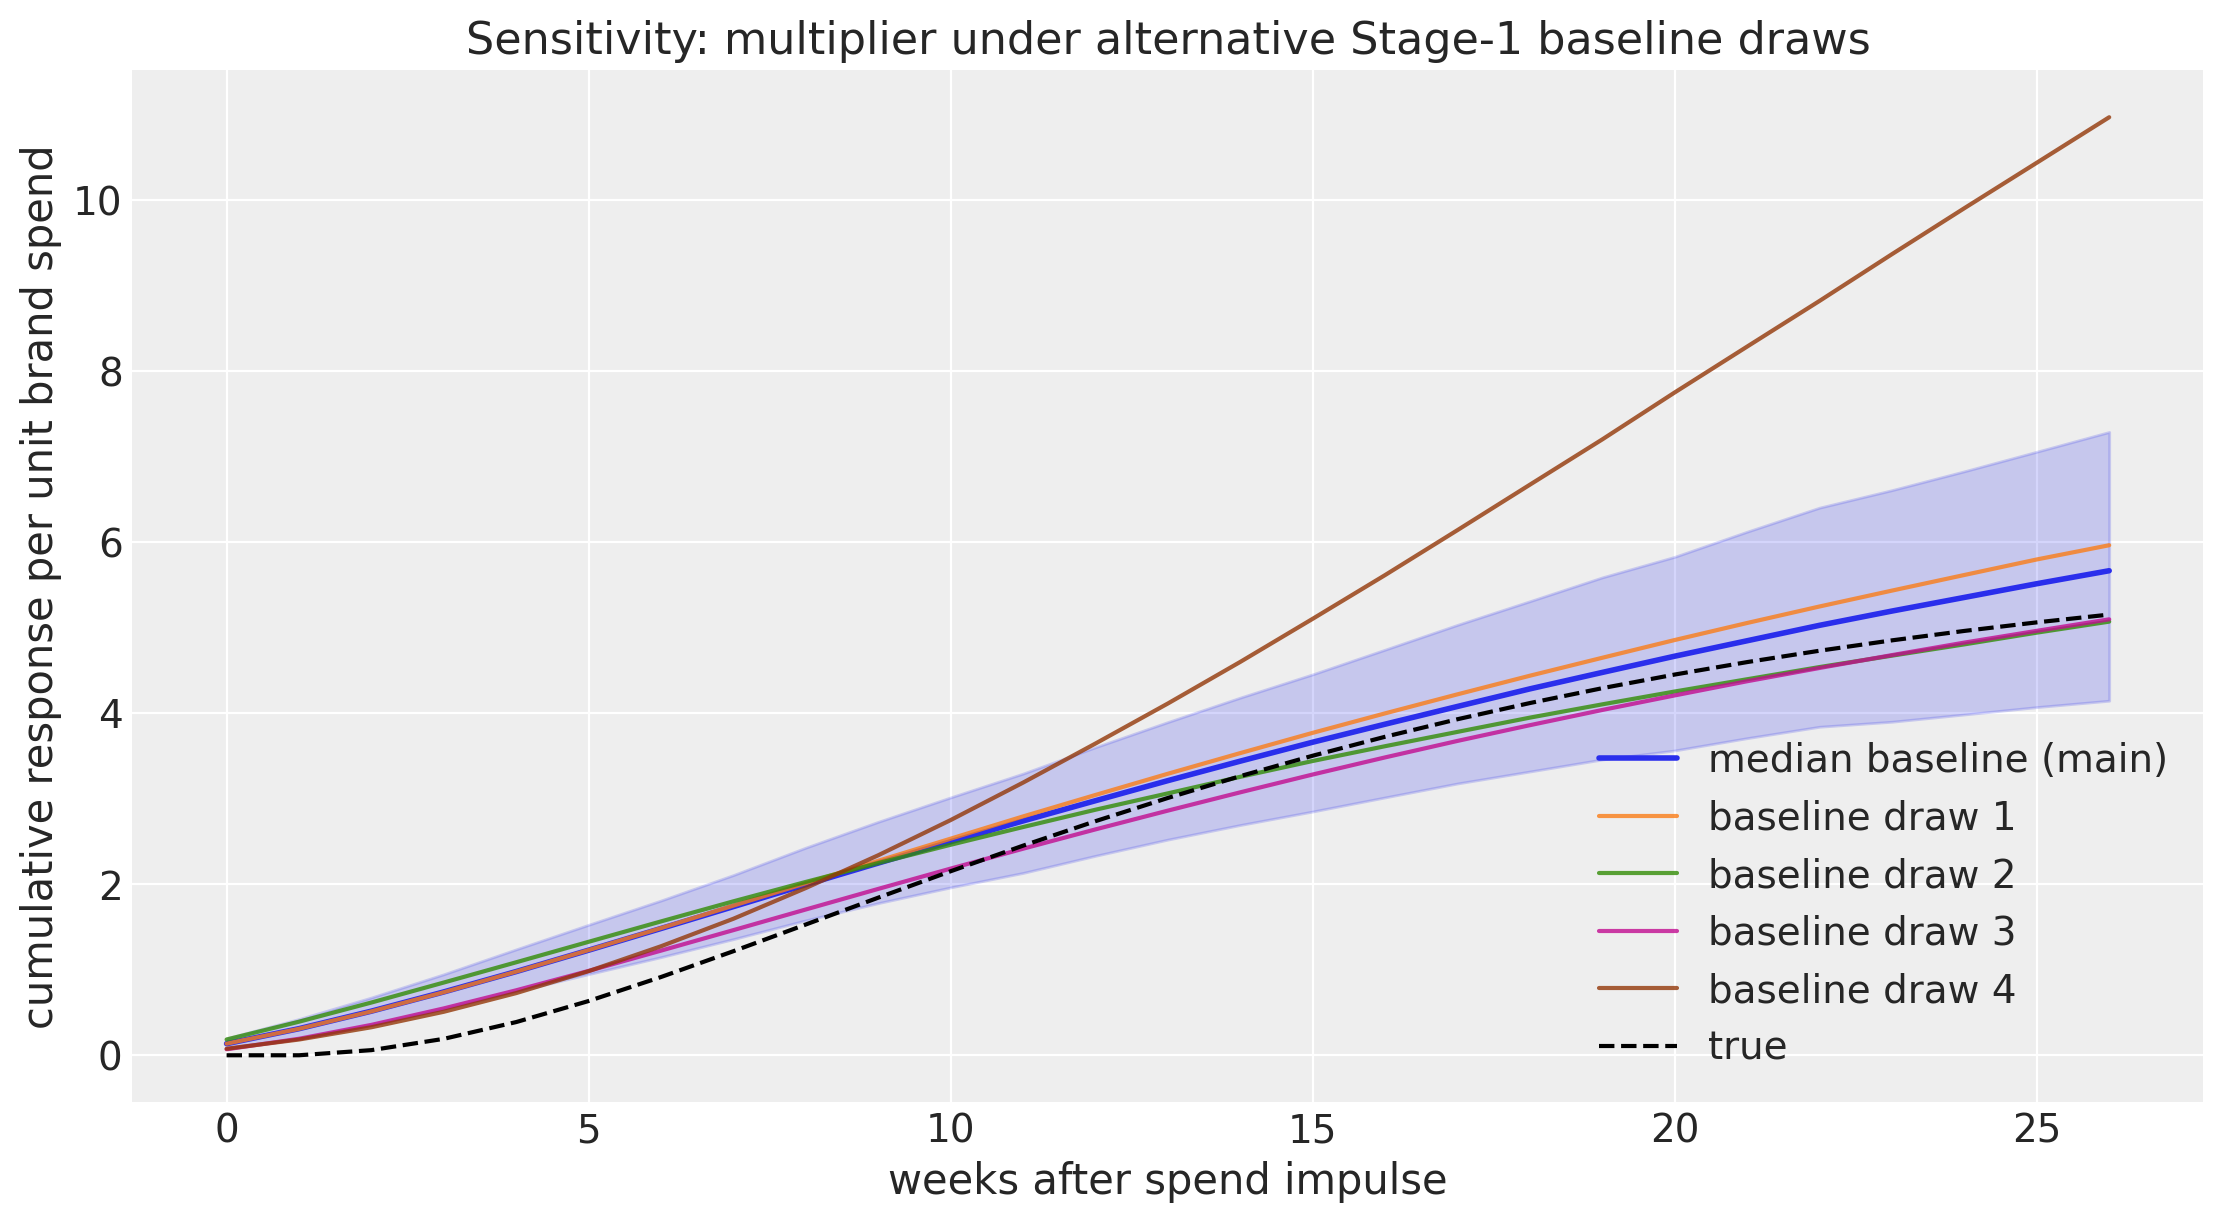

In [39]:
main_curve = cum_multiplier.sel(response="baseline", exog="brand_spend")
main_median = main_curve.median(dim=("chain", "draw"))
main_hdi = az.hdi(main_curve, prob=0.94)

fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(
    main_curve["horizon"],
    main_hdi.sel(ci_bound="lower"),
    main_hdi.sel(ci_bound="upper"),
    alpha=0.2,
    color="C0",
)
ax.plot(
    main_curve["horizon"],
    main_median,
    color="C0",
    linewidth=2,
    label="median baseline (main)",
)
for i, (label, curve) in enumerate(sensitivity_curves.items()):
    ax.plot(
        curve["horizon"],
        curve,
        linewidth=1.5,
        alpha=0.8,
        color=f"C{i + 1}",
        label=label,
    )
ax.plot(
    np.arange(horizon + 1),
    true_curves["baseline"],
    color="black",
    linestyle="--",
    label="true",
)
ax.legend(loc="lower right")
ax.set(
    title="Sensitivity: multiplier under alternative Stage-1 baseline draws",
    xlabel="weeks after spend impulse",
    ylabel="cumulative response per unit brand spend",
);

Here the conclusions are stable across baseline draws because the baseline is tightly identified by three and a half years of clean data. In noisier settings the honest options are to run Stage 2 for many Stage-1 draws and mix the posteriors, or to move toward a joint model in which the funnel equations and the MMM are estimated together (see {ref}`mmm_funnel_mueffect` for a step in that direction).

## Assumptions, Caveats, and Extensions

- **Mediation completeness.** The workflow credits brand only through the measured mindset metrics and the baseline. If brand marketing works through additional unmeasured paths, the total effect is underestimated. Choose tracking metrics that cover the funnel your category actually has.
- **Exogeneity of brand spend.** The causal reading of the dynamic multiplier requires that flights do not respond to weekly demand or awareness shocks. Annual planning calendars usually satisfy this; performance-triggered brand boosts would not, and would require identification arguments beyond this notebook.
- **The baseline is a residual.** Anything omitted from Stage 1 (price, distribution, promotions, competitor actions) lands in the baseline. If such a driver correlates with the flight calendar, the VARX will misattribute it to brand. Include known drivers as controls in Stage 1 or as variables in Stage 2.
- **Unit roots and cointegration.** With genuinely integrated series, the levels VAR should be replaced (or at least cross-checked) with a VECM as in Cain (2022). The stationarity checks of the Stage-2 preparation section are the guardrail.
- **Calibration.** Brand lift studies (search or survey lift) can anchor the spend-to-awareness link, in the same spirit as the sales lift tests of {ref}`mmm_lift_test`.

### Key Takeaways

1. A standard MMM estimates the *direct short-term* effect of brand media, which is typically near zero. That number is correct and, on its own, misleading.
2. A time-varying intercept turns the MMM baseline from a nuisance into a measurable quantity that contains the accumulated brand effect.
3. A Bayesian VARX on {baseline, brand metrics} with brand spend exogenous recovers the long-run transmission with full posterior uncertainty, and needs no structural identification for the planner-set spend input.
4. Report the horizon convention explicitly, and never multiply total historical spend by a truncated multiplier to decompose in-sample sales: convolve the spend path instead.
5. Two-stage inference understates uncertainty; check robustness across Stage-1 posterior draws.

### References

- Cain, P. M. (2022). "Modelling short- and long-term marketing effects in the consumer purchase journey." *International Journal of Research in Marketing*, 39(1), 96-116.
- O'Sullivan, R. (2025). [Capturing the long-term causal effect of brand marketing](https://medium.com/@raz1470/capturing-the-long-term-causal-effect-of-brand-marketing-bc577621a627).
- Oulton, N. / 1749.io. [Measuring Marketing Effectiveness Over the Long-Term](https://1749.io/learn/f/measuring-marketing-effectiveness-over-the-long-term).
- Dekimpe, M. G., & Hanssens, D. M. (1999). "Sustained spending and persistent response: A new look at long-term marketing profitability." *Journal of Marketing Research*, 36(4), 397-412.

In [40]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,impulso

Last updated: Sat, 01 Aug 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
impulso       : 0.0.10

arviz         : 1.2.0
graphviz      : 0.21
impulso       : 0.0.10
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
xarray        : 2026.4.0

Watermark: 2.6.0

